<div class="alert alert-block alert-info">

[1. Understanding the Business](#1-bullet)<br>

[2. Pré-processing steps](#2-bullet)<br>
- [2.1 Import the needed libraries](#2.1-bullet)<br>
- [2.2 Import the dataset](#2.2-bullet)<br>
- [2.3. Data pre-processing](#2.3-bullet)<br>
    - [2.3.0. Data exploration](#2.3.0-bullet)<br>
        - [2.3.0.1 Inicial exploration](#2.3.0.1-bullet)<br>
        - [2.3.0.2 Duplicated Rows](#2.3.0.2-bullet)<br>
        - [2.3.0.3 Check for null or unknown values](#2.3.0.3-bullet)<br>
        - [2.3.0.4 Features with different patterns](#2.3.0.4-bullet)<br>
        - [2.3.0.5 Drop features](#2.3.0.5-bullet)<br>
    - [2.3.1. Treatment of Outliers](#2.3.1-bullet)<br>
        - [2.3.1.1 Graphical analysis](#2.3.1.1-bullet)<br>
        - [2.3.1.2 Removing outliers](#2.3.1.2-bullet)<br> 
    - [2.3.2. Data split](#2.3.2-bullet)<br>
    - [2.3.3. Test Data Pretreatment](#2.3.3-bullet)<br>
    - [2.3.4. Encoding](#2.3.4-bullet)<br>
    - [2.3.5. Scaling](#2.3.5-bullet)<br>
    - [2.3.6. Fill nan](#2.3.6-bullet)<br>
    - [2.3.6. Under/Over sampling](#2.3.6-bullet)<br>
    - [2.3.7. Encoding](#2.3.7-bullet)<br>

[3. Feature Selection](#3-bullet)<br>
- [3.1 Univariate variables](#3.1-bullet)<br>
- [3.2 Lasso](#3.2-bullet)<br>
- [3.3 KBest - Mutual Info Classification](#3.3-bullet)<br>
- [3.4 ANOVA](#3.4-bullet)<br>
- [3.5 Random Forests](#3.5-bullet)<br>
- [3.6 Feature Selection Summary](#3.6-bullet)<br>

[4. Model application/selection](#4-bullet)<br>
- [4.1 Logistic Regression](#4.1-bullet)<br>
- [4.2 Gaussian Naive Bayes](#4.2-bullet)<br>
- [4.3 Instance Based Learning (KNN)](#4.3-bullet)<br>
- [4.4 Neural Networks](#4.4-bullet)<br>
- [4.5 Decision Trees](#4.5-bullet)<br>
- [4.6 Random Forests](#4.6-bullet)<br>
- [4.7 Adaboost](#4.7-bullet)<br>
- [4.8 Gradient Boost](#4.8-bullet)<br>
- [4.9 Support Vector Machines](#4.9-bullet)<br>
- [4.10 Stacking](#4.10-bullet)<br>
- [4.11 Model Performances](#4.11-bullet)<br>
    
</div>

<a class="anchor" id="1-bullet">

# 1. Understanding the Business
    
</a>

**Hospital readmissions** are a major issue in healthcare, signaling care quality gaps and increasing costs. Quick patient re-admissions after discharge highlight care shortcomings and add financial strain to the healthcare system, especially for diabetic patients. Predicting these readmissions is crucial for enhancing patient care and saving costs significantly.

To address the major problem in healthcare, it would be useful to predict whether a patient will be readmitted to hospital within X days of discharge. To address the problem, we will use the following criteria: 

- The patient will not be readmitted.
- The patient will be readmitted in less than 30 days.

<a class="anchor" id="2-bullet">

# 2. Pre-processing steps
    
</a>

<a class="anchor" id="2.1-bullet">

## 2.1 Import the needed libraries
    
</a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
from math import ceil
import os
import sqlite3
import scipy.stats as stats
import math
import random
import time


from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from ydata_profiling import ProfileReport
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr
import category_encoders as ce
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.feature_selection import RFE
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.utils import resample
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import f_classif
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.datasets import make_classification

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score




import warnings


# for better resolution plots
%config InlineBackend.figure_format = 'retina' # optionally, you can change 'svg' to 'retina'

# Setting seaborn style
sns.set()

warnings.filterwarnings('ignore')

<a class="anchor" id="2.2-bullet">

## 2.2 Import the dataset
    
</a>

In [2]:
data = pd.read_csv('../data/train.csv')

data.head(3)

,encounter_id,country,patient_id,race,gender,age,weight,payer_code,outpatient_visits_in_previous_year,emergency_visits_in_previous_year,...,secondary_diagnosis,additional_diagnosis,number_diagnoses,glucose_test_result,a1c_test_result,change_in_meds_during_hospitalization,prescribed_diabetes_meds,medication,readmitted_binary,readmitted_multiclass
0,533253,USA,70110,Caucasian,Female,[70-80),?,?,0,0,...,276,466,8,NaN,NaN,No,No,[],No,>30 days
1,426224,USA,29775006,AfricanAmerican,Male,[50-60),?,?,0,0,...,785,162,9,NaN,NaN,No,Yes,['insulin'],No,No
2,634063,USA,80729253,Caucasian,Female,[60-70),?,?,0,0,...,135,250,6,NaN,NaN,Ch,Yes,"['glimepiride', 'insulin']",No,No


<a class="anchor" id="2.3-bullet">

## 2.3. Data pre-processing
    
</a>

<a class="anchor" id="2.3.0-bullet">

### 2.3.0. Data exploration
    
</a>

<a class="anchor" id="2.3.0.1-bullet">

#### 2.3.0.1 Inicial exploration

</a>

In [3]:
data.set_index('encounter_id', inplace=True)

In [4]:
data_preprocessed = data.copy()

In [5]:
# data.info()

In [6]:
data[['outpatient_visits_in_previous_year', 'emergency_visits_in_previous_year',
      'inpatient_visits_in_previous_year', 'average_pulse_bpm', 'length_of_stay_in_hospital', 'number_lab_tests',
      'non_lab_procedures', 'number_of_medications', 'number_diagnoses']] = data[['outpatient_visits_in_previous_year',
                                                                                  'emergency_visits_in_previous_year', 'inpatient_visits_in_previous_year', 'average_pulse_bpm',
                                                                                  'length_of_stay_in_hospital', 'number_lab_tests', 'non_lab_procedures', 'number_of_medications',
                                                                                  'number_diagnoses']].astype("int32")

In [7]:
# data.describe().T

In [8]:
# data.describe(include='O').T

In [9]:
# pd.value_counts(data["readmitted_binary"])

<a class="anchor" id="2.3.0.2-bullet">

#### 2.3.0.2 duplicated rows

</a>

In [10]:
# print(data.duplicated().sum(), 'duplicates in data')

<a class="anchor" id="2.3.0.3-bullet">

#### 2.3.0.3 Check for null or unknown values

</a>

In [11]:
# (data.isna().sum()[data.isnull().sum() > 1] / len(data) * 100).round(2)

In [12]:
# question_mark_count = (data == '?').sum()
# (question_mark_count[question_mark_count > 0] / len(data) * 100).round(2)

In [13]:
# not_mapped = (data == 'Not Mapped').sum()
# (not_mapped[not_mapped > 0] / len(data) * 100).round(2)

In [14]:
# not_available = (data == 'Not Available').sum()
# (not_available[not_available > 0] / len(data) * 100).round(2)

In [15]:
data_preprocessed.replace('?', np.nan, inplace=True)
data_preprocessed.replace('Not Mapped', np.nan, inplace=True)
data_preprocessed.replace('Not Available', np.nan, inplace=True)

In [16]:
# (data_preprocessed.isna().sum()[
#  data.isnull().sum() > 1] / len(data) * 100).round(2)

<a class="anchor" id="2.3.0.4-bullet">

#### 2.3.0.4 features with different patterns

</a>

In [17]:
data_processed = data_preprocessed.copy()

In [18]:
# replace nan to unknown

data_processed['a1c_test_result'].fillna('didnt take', inplace=True)
data_processed['glucose_test_result'].fillna('didnt take', inplace=True)
data_processed['admission_source'].fillna('Unkown', inplace=True)
data_processed['discharge_disposition'] = data_processed['discharge_disposition'].replace(
    np.nan, 'Not Mapped')
data_processed['admission_type'] = data_processed['admission_type'].replace(
    np.nan, 'Unknown')
data_processed['payer_code'] = data_processed['payer_code'].replace(
    np.nan, 'Unknown')
data_processed['primary_diagnosis'] = data_processed['primary_diagnosis'].replace(
    np.nan, 'Unknown')
data_processed['secondary_diagnosis'] = data_processed['secondary_diagnosis'].replace(
    np.nan, 'Unknown')
data_processed['additional_diagnosis'] = data_processed['additional_diagnosis'].replace(
    np.nan, 'Unknown')
data_processed['race'] = data_processed['race'].replace(np.nan, 'Unknown')
data_processed['race'] = data_processed['race'].replace('Other', 'Unknown')

In [19]:
# (data_processed.isna().sum()[
#  data.isnull().sum() > 1] / len(data) * 100).round(2)

In [20]:
# age will be filled later, after the scaling, using knn

In [21]:
# pd.value_counts(data['glucose_test_result'], dropna=False)

In [22]:
data_processed['glucose_test_result'] = data_preprocessed['glucose_test_result'].replace(
    ['>200', '>300'], 'High glucose')
pd.value_counts(data_processed['glucose_test_result'], dropna=False)

glucose_test_result
NaN             67548
High glucose     1882
Norm             1806
Name: count, dtype: int64

In [23]:
# pd.value_counts(data['a1c_test_result'], dropna=False)

In [24]:
data_processed['a1c_test_result'] = data_processed['a1c_test_result'].replace([
                                                                              '>8', '>7'], 'High a1c')
pd.value_counts(data_processed['a1c_test_result'], dropna=False)

a1c_test_result
didnt take    59320
High a1c       8413
Norm           3503
Name: count, dtype: int64

In [25]:
def transform_medication(meds):
    if meds == "[]":
        return 'no medication'
    elif 'insulin' in meds:
        return 'medication with insulin'
    else:
        return 'medication without insulin'


data_processed['medication'] = data_processed['medication'].apply(
    transform_medication)

pd.value_counts(data_processed['medication'], dropna=False)

medication
medication with insulin       38105
medication without insulin    16785
no medication                 16346
Name: count, dtype: int64

In [26]:
discharge_hospital_list = [
    "Discharged/transferred to SNF",
    "Discharged/transferred to another short term hospital",
    "Discharged/transferred to another rehab fac including rehab units of a hospital .",
    "Discharged/transferred to another type of inpatient care institution",
    "Discharged/transferred to ICF",
    "Discharged/transferred to a long term care hospital.",
    "Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital",
    "Discharged/transferred within this institution to Medicare approved swing bed",
    "Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.",
    "Admitted as an inpatient to this hospital",
    "Discharged/transferred/referred to this institution for outpatient services",
    "Discharged/transferred/referred another institution for outpatient services",
    "Discharged/transferred to a federal health care facility.",
    "Neonate discharged to another hospital for neonatal aftercare",
    "Still patient or expected to return for outpatient services",

]

discharge_home_list = [
    "Discharged to home",
    "Discharged/transferred to home with home health service",
    "Left AMA",
    "Discharged/transferred to home under care of Home IV provider"
]

expired_list = [
    "Expired",
    "Hospice / medical facility",
    "Hospice / home",
    "Expired at home. Medicaid only, hospice.",
    "Expired in a medical facility. Medicaid only, hospice."
]

unkown_list = [
    "Not Mapped"
]

# Now let's change the values according to the previous lists.

data_processed['discharge_disposition'] = (
    np.where(
        data_processed['discharge_disposition'].isin(
            discharge_hospital_list), 'discharge_hospital',
        np.where(
            data_processed['discharge_disposition'].isin(
                discharge_home_list), 'discharge_home',
            np.where(
                data_processed['discharge_disposition'].isin(
                    expired_list), 'expired',
                np.where(
                    data_processed['discharge_disposition'].isin(
                        unkown_list), 'Unkown',
                    'outside_lists'
                )
            )
        )
    )
)

data_processed['discharge_disposition'].value_counts(dropna=False)

discharge_disposition
discharge_home        51763
discharge_hospital    14543
Unkown                 3269
expired                1661
Name: count, dtype: int64

In [27]:
def code_to_score(c):
    c2 = ["250.4", "250.5", "250.6", "250.7", "342", "343", "344", "582", "583", "585",
          "586", "587", "V56", "334.1", "344.9", "403.01", "403.11", "403.91", "404.02", "404.03",
          "404.12", "404.13", "404.92", "404.93", "588", "V42.0", "V45.1", "170", "171", "172", "190", "191", "192", "193", "194", "195", "238.6"]
    c2prefixes = ["14", "15", "16", "174", "175", "176", "177", "178", "179",
                  "18", "200", "201", "202", "203", "204", "205", "206", "207", "208"]
    c3 = ["042", "043", "044", "456.0", "456.1", "456.2", "572.2",
          "572.3", "572.4", "572.5", "572.6", "572.7", "572.8"]
    c6prefixes = ["196", "197", "198", "199"]
    if any(value in c for value in c2) | any(c.startswith(prefix) for prefix in c2prefixes):
        score = 2
    elif any(value in c for value in c3):
        score = 3
    elif any(c.startswith(prefix) for prefix in c6prefixes):
        score = 6
    elif c == '?':
        score = 0
    else:
        score = 1
    return score

In [28]:
data_processed['primary_diagnosis'] = data_processed['primary_diagnosis'].apply(
    code_to_score)
data_processed['secondary_diagnosis'] = data_processed['secondary_diagnosis'].apply(
    code_to_score)
data_processed['additional_diagnosis'] = data_processed['additional_diagnosis'].apply(
    code_to_score)

In [29]:
data_processed["Charlson_Cormobility_Index"] = (
    data_processed['primary_diagnosis'] + data_processed['secondary_diagnosis'] +
    data_processed['additional_diagnosis']
)

data_processed = data_processed.drop(
    ["primary_diagnosis", "secondary_diagnosis", "additional_diagnosis"], axis=1)
data_processed['Charlson_Cormobility_Index'].value_counts(dropna=False)

Charlson_Cormobility_Index
3     60352
4      8869
5       704
9       589
8       380
13      140
14      126
18       36
10       22
6        18
Name: count, dtype: int64

In [30]:
data_processed['encounter_count'] = data_processed.groupby(
    'patient_id')['patient_id'].transform('size')

In [31]:
age_range = [data_processed['age'] == '[0-10)',
             data_processed['age'] == '[10-20)',
             data_processed['age'] == '[20-30)',
             data_processed['age'] == '[30-40)',
             data_processed['age'] == '[40-50)',
             data_processed['age'] == '[50-60)',
             data_processed['age'] == '[60-70)',
             data_processed['age'] == '[70-80)',
             data_processed['age'] == '[80-90)',
             data_processed['age'] == '[90-100)']

age_number = [5, 15, 25, 35, 45, 55, 65, 75, 85, 95]

data_processed['age'] = np.select(age_range, age_number)

data_processed['age'].replace(0, np.nan, inplace=True)

data_processed['age'].value_counts(dropna=False)

age
75.0    17359
65.0    14908
85.0    11510
55.0    11423
45.0     6418
NaN      3557
35.0     2536
95.0     1875
25.0     1071
15.0      474
5.0       105
Name: count, dtype: int64

In [32]:
data_processed['admission_source'] = data_processed['admission_source'].str.strip()

top_admission_source = ['Emergency Room', 'Physician Referral', 'Transfer from a hospital',
                        'Transfer from another health care facility', 'Clinic Referral', 'Unkown']

data_processed['admission_source'] = (np.where(data_processed['admission_source'].isin(
    top_admission_source), data_processed['admission_source'], 'Others'))

data_processed['admission_source'].value_counts(dropna=False)

admission_source
Emergency Room                                40319
Physician Referral                            20678
Unkown                                         4718
Transfer from a hospital                       2230
Transfer from another health care facility     1562
Others                                          950
Clinic Referral                                 779
Name: count, dtype: int64

In [33]:
data_processed['payer_code'] = np.where(
    data_processed['payer_code'] == 'Unknown', 0, 1)
data_processed['prescribed_diabetes_meds'] = np.where(
    data_processed['prescribed_diabetes_meds'] == 'No', 0, 1)
data_processed['change_in_meds_during_hospitalization'] = np.where(
    data_processed['change_in_meds_during_hospitalization'] == 'No', 0, 1)
data_processed['gender'] = np.where(data_processed['gender'] == 'Male', 0, 1)

In [34]:
data_processed['readmitted_binary'] = np.where(
    data_processed['readmitted_binary'] == 'No', 0, 1)

<a class="anchor" id="2.3.0.5-bullet">

#### 2.3.0.5 Drop features

</a>

In [35]:
# Droping features we will not use as:
# 'country': all the rows has the same value so, it doesn't add any relevant information.
# 'weight': we have only 3% not null.
# 'patiend_id': is only an identifier.
# 'medical_specialty': only 50% not null.

drop_variables = ['country', 'weight', "patient_id",
                  'medical_specialty', 'readmitted_multiclass']

data_processed = data_processed.drop(drop_variables, axis=1)

data_processed.columns

Index(['race', 'gender', 'age', 'payer_code',
       'outpatient_visits_in_previous_year',
       'emergency_visits_in_previous_year',
       'inpatient_visits_in_previous_year', 'admission_type',
       'average_pulse_bpm', 'discharge_disposition', 'admission_source',
       'length_of_stay_in_hospital', 'number_lab_tests', 'non_lab_procedures',
       'number_of_medications', 'number_diagnoses', 'glucose_test_result',
       'a1c_test_result', 'change_in_meds_during_hospitalization',
       'prescribed_diabetes_meds', 'medication', 'readmitted_binary',
       'Charlson_Cormobility_Index', 'encounter_count'],
      dtype='object')

<a class="anchor" id="2.3.1-bullet">

### 2.3.1. Treatment of Outliers
    
</a>

<a class="anchor" id="2.3.1.1-bullet">

#### 2.3.1.1 Graphical analysis
    
</a>

In [36]:
data_graph = data_processed.copy()

In [37]:
numerical_variables = ['age', 'outpatient_visits_in_previous_year', 'emergency_visits_in_previous_year',
                       'inpatient_visits_in_previous_year', 'average_pulse_bpm', 'length_of_stay_in_hospital', 'number_lab_tests',
                       'non_lab_procedures', 'number_of_medications', 'number_diagnoses', 'Charlson_Cormobility_Index', "encounter_count"]

boolean_variables = ['payer_code', 'prescribed_diabetes_meds',
                     'change_in_meds_during_hospitalization', 'gender', 'readmitted_binary']


categorical_variables = data_graph.columns.drop(
    numerical_variables+boolean_variables).to_list()
categorical_variables

['race',
 'admission_type',
 'discharge_disposition',
 'admission_source',
 'glucose_test_result',
 'a1c_test_result',
 'medication']

In [38]:
# sns.set()

# fig, axes = plt.subplots(
#     2, ceil(len(numerical_variables) / 2), figsize=(20, 11))

# # Plot data
# for ax, feat in zip(axes.flatten(), numerical_variables):
#     ax.hist(data_graph[feat])
#     ax.set_title(feat, y=-0.13)

# # Layout
# title = "Numeric Variables' Histograms"

# plt.suptitle(title)

# # Save the figure
# if not os.path.exists(os.path.join('..', 'figures', 'exp_analysis')):
#     # if the exp_analysis directory is not present then create it first
#     os.makedirs(os.path.join('..', 'figures', 'exp_analysis'))

# plt.savefig(os.path.join('..', 'figures', 'exp_analysis',
#             'numeric_variables_histograms.png'), dpi=200)

# plt.show()

In [39]:
# sns.set()


# fig, axes = plt.subplots(
#     2, ceil(len(numerical_variables) / 2), figsize=(20, 11))

# # Plot data
# for ax, feat in zip(axes.flatten(), numerical_variables):
#     sns.boxplot(x=data_graph[feat], ax=ax)

# # Layout
# title = "Numeric Variables' Box Plots"

# plt.suptitle(title)

# # Save the figure
# if not os.path.exists(os.path.join('..', 'figures', 'exp_analysis')):
#     # if the exp_analysis directory is not present then create it first
#     os.makedirs(os.path.join('..', 'figures', 'exp_analysis'))

# plt.savefig(os.path.join('..', 'figures', 'exp_analysis',
#             'numeric_variables_boxplots.png'), dpi=200)

# plt.show()

In [40]:
# # Pairwise Relationship of Numerical Variables
# sns.set()

# # Setting pairplot
# sns.pairplot(data_graph[numerical_variables], diag_kind="hist")

# # Layout
# plt.subplots_adjust(top=0.95)
# plt.suptitle("Pairwise Relationship of Numerical Variables", fontsize=20)

# # Save the figure
# if not os.path.exists(os.path.join('..', 'figures', 'exp_analysis')):
#     # if the exp_analysis directory is not present then create it first
#     os.makedirs(os.path.join('..', 'figures', 'exp_analysis'))

# plt.savefig(os.path.join('..', 'figures', 'exp_analysis',
#             'pairwise_relationship_of_numerical_variables.png'), dpi=200)
# plt.show()

In [41]:
correlation_matrix = data_graph[numerical_variables].corr()
correlation_matrix

,age,outpatient_visits_in_previous_year,emergency_visits_in_previous_year,inpatient_visits_in_previous_year,average_pulse_bpm,length_of_stay_in_hospital,number_lab_tests,non_lab_procedures,number_of_medications,number_diagnoses,Charlson_Cormobility_Index,encounter_count
age,1.000000,0.023540,-0.084700,-0.039791,0.004040,0.112044,0.023019,-0.031962,0.043753,0.244500,0.013404,-0.054013
outpatient_visits_in_previous_year,0.023540,1.000000,0.089280,0.103610,0.004913,-0.007030,-0.006146,-0.021830,0.044112,0.092945,0.010501,0.093308
emergency_visits_in_previous_year,-0.084700,0.089280,1.000000,0.271818,-0.007844,-0.009223,0.001985,-0.036403,0.015796,0.057487,0.002678,0.250297
inpatient_visits_in_previous_year,-0.039791,0.103610,0.271818,1.000000,0.000458,0.075453,0.042435,-0.065781,0.066215,0.107992,0.034984,0.609251
average_pulse_bpm,0.004040,0.004913,-0.007844,0.000458,1.000000,0.002900,0.001046,-0.001729,0.001999,0.000141,-0.000686,0.001013
length_of_stay_in_hospital,0.112044,-0.007030,-0.009223,0.075453,0.002900,1.000000,0.316575,0.192387,0.464457,0.220691,0.072208,0.040250
number_lab_tests,0.023019,-0.006146,0.001985,0.042435,0.001046,0.316575,1.000000,0.055058,0.265226,0.154756,0.014080,-0.000378
non_lab_procedures,-0.031962,-0.021830,-0.036403,-0.065781,-0.001729,0.192387,0.055058,1.000000,0.387917,0.074452,0.039564,-0.068053
number_of_medications,0.043753,0.044112,0.015796,0.066215,0.001999,0.464457,0.265226,0.387917,1.000000,0.261705,0.023334,0.051321
number_diagnoses,0.244500,0.092945,0.057487,0.107992,0.000141,0.220691,0.154756,0.074452,0.261705,1.000000,0.060050,0.093003


In [42]:
# # Prepare figure
# fig = plt.figure(figsize=(12, 10))

# # Obtain correlation matrix. Round the values to 2 decimal cases. Use the DataFrame corr() and round() method.
# corr = np.round(data_graph[numerical_variables].corr(
#     method="pearson"), decimals=2)

# # Build annotation matrix (values above |0.5| will appear annotated in the plot)
# mask_annot = np.absolute(corr.values) >= 0.5

# # Try to understand what this np.where() does
# annot = np.where(mask_annot, corr.values, np.full(corr.shape, ""))

# # Plot heatmap of the correlation matrix
# sns.heatmap(data=corr, annot=annot, cmap=sns.diverging_palette(220, 10, as_cmap=True),
#             fmt='s', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)

# # Layout
# fig.subplots_adjust(top=0.95)
# fig.suptitle("Correlation Matrix", fontsize=20)

# # Save the figure
# plt.savefig(os.path.join('..', 'figures', 'exp_analysis',
#             'correlation_matrix.png'), dpi=200)

# plt.show()

<a class="anchor" id="2.3.1.2-bullet">

#### 2.3.1.2 Removing outliers
    
</a>

In [43]:
data_outlier = data_graph.copy()

In [44]:
# Outlier using the IQR method

# Calculates the interquartile range (IQR) for each numerical variable.
Q1 = data_outlier[numerical_variables].quantile(0.25)
Q3 = data_outlier[numerical_variables].quantile(0.75)
IQR = Q3 - Q1

# Identify the outliers:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers for each variable:
outliers = ((data_outlier[numerical_variables] < lower_bound) |
            (data_outlier[numerical_variables] > upper_bound))

# Count the number of outliers per each variable:
num_outliers_per_variable = outliers.sum()

# Show the amount of outliers per variable:
print("Outliers per variable:")
print(pd.concat([num_outliers_per_variable, (num_outliers_per_variable /
      len(data) * 100).round(2)], axis=1).rename(columns={0: 'N°', 1: '%'}))

Outliers per variable:
                                       N°      %
age                                   579   0.81
outpatient_visits_in_previous_year  11649  16.35
emergency_visits_in_previous_year    7994  11.22
inpatient_visits_in_previous_year    4996   7.01
average_pulse_bpm                       0   0.00
length_of_stay_in_hospital           1582   2.22
number_lab_tests                       95   0.13
non_lab_procedures                   3478   4.88
number_of_medications                1794   2.52
number_diagnoses                      207   0.29
Charlson_Cormobility_Index          10884  15.28
encounter_count                      7697  10.80


In [45]:
# We are not going to 'treat' the variable 'age' since the 'outliers' looks like real data without without such exaggerated values.

# For 'outpatient_visits_in_previous_year' there is a high concentration in the value = 0. The maximum value is 42 (just one person)
# All the 'outliers' looks reasonable since is possible to go to an outpatient visits that amount of times in 365 days.
# We are going to cap the maximum value in 10 since we assume that all the outilers express the same behavior.
data_outlier['outpatient_visits_in_previous_year'] = data_outlier['outpatient_visits_in_previous_year'].clip(
    lower=0, upper=10)

# For 'emergency_visits_in_previous_year' there is a high concentration in the value = 0. The maximum value is 76 (one person)
# The maximun amount sounds unlikely but could be real. In this case we are going to cap the maximum valie in 10 since we assume that
# all the outliers express the same behavior and there is just a few rows with values higher than 10.
data_outlier['emergency_visits_in_previous_year'] = data_outlier['emergency_visits_in_previous_year'].clip(
    lower=0, upper=10)

# For 'inpatient_visits_in_previous_year'  there is a high concentration in the value = 0 and 1. The maximum value is 21 (one person)
# All the 'outliers' looks reasonable since is possible to go to an inpatient visits that amount of times in 365 days.
# We are going to cap the maximum value in 10 since we assume that all the outilers express the same behavior.
data_outlier['inpatient_visits_in_previous_year'] = data_outlier['inpatient_visits_in_previous_year'].clip(
    lower=0, upper=10)


# For 'length_of_stay_in_hospital' the distributions all the 'outliers' looks reasonable so, we are not going to treat them

# For number_lab_tests we are going to cap the maximum value in 96 (upper bound) since we assume that all the outilers express the same behavior.
data_outlier['number_lab_tests'] = data_outlier['number_lab_tests'].clip(
    lower=1, upper=upper_bound['number_lab_tests'] // 1)

# For non_lab_procedures there is a high concentration in the values = 0 and 1. The ouliers has a value of 6 and it looks reasonable so, we are not going to treat them.

# For number_of_medications we are going to cap the maximum value in 35 (upper bound) since we assume that all the outilers express the same behavior.
data_outlier['number_of_medications'] = data_outlier['number_of_medications'].clip(
    lower=1, upper=upper_bound['number_of_medications'] // 1)

# For number_diagnoses it has outliers on both the left and right sides. In the left the outliers take a value = 1 and since it looks normal, we are going to let those roes
# without modification. On the other hand, in the right side we are going to cap the maximum value in 13 (upper bound) since we assume that all the outilers express the same behavior.
data_outlier['number_diagnoses'] = data_outlier['number_diagnoses'].clip(
    lower=1, upper=upper_bound['number_diagnoses'] // 1)

<a class="anchor" id="2.3.2-bullet">

### 2.3.2. Data split
    
</a>

In [46]:
data_split = data_outlier.copy()

In [47]:
X = data_split.drop(['readmitted_binary'], axis=1)
y = data_split[['readmitted_binary']]

In [48]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3,
                                                  random_state=0,
                                                  stratify=y,
                                                  shuffle=True)

<a class="anchor" id="2.3.3-bullet">

### 2.3.3. Test Data Pretreatment
    
</a>

In [49]:
df_test = pd.read_csv('../data/test.csv')

df_test.head(3)

,encounter_id,country,patient_id,race,gender,age,weight,payer_code,outpatient_visits_in_previous_year,emergency_visits_in_previous_year,...,number_of_medications,primary_diagnosis,secondary_diagnosis,additional_diagnosis,number_diagnoses,glucose_test_result,a1c_test_result,change_in_meds_during_hospitalization,prescribed_diabetes_meds,medication
0,499502,USA,103232799,Caucasian,Male,[80-90),?,HM,0,0,...,14,491,414,250,6,NaN,NaN,No,Yes,['metformin']
1,447319,USA,93395304,Caucasian,Male,[20-30),?,HM,0,0,...,7,250.13,70,794,7,>300,NaN,No,No,[]
2,309126,USA,6281586,AfricanAmerican,Male,[30-40),?,?,0,0,...,12,786,250.6,536,6,NaN,NaN,No,Yes,['insulin']


In [50]:
df_test.set_index('encounter_id', inplace=True)

In [51]:
# print(df_test.duplicated().sum(), 'duplicates in data')

In [52]:
# (df_test.isna().sum()[df_test.isnull().sum() > 1] /
#  len(df_test) * 100).round(2)

In [53]:
# question_mark_count_test = (df_test == '?').sum()
# (question_mark_count_test[question_mark_count_test >
#  0] / len(df_test) * 100).round(2)

In [54]:
# not_mapped_test = (df_test == 'Not Mapped').sum()
# (not_mapped_test[not_mapped_test > 0] / len(df_test) * 100).round(2)

In [55]:
df_test.replace('?', np.nan, inplace=True)
df_test.replace('Not Mapped', np.nan, inplace=True)
df_test.replace('Not Available', np.nan, inplace=True)

In [56]:
# (df_test.isna().sum()[df_test.isnull().sum() > 1] /
#  len(df_test) * 100).round(2)

In [57]:
df_test_copy = df_test.copy()

In [58]:
df_test_copy['a1c_test_result'].fillna('didnt take', inplace=True)
df_test_copy['glucose_test_result'].fillna('didnt take', inplace=True)
df_test_copy['admission_source'].fillna('Unkown', inplace=True)
df_test_copy['discharge_disposition'] = df_test_copy['discharge_disposition'].replace(
    np.nan, 'Not Mapped')
df_test_copy['admission_type'] = df_test_copy['admission_type'].replace(
    np.nan, 'Unknown')
df_test_copy['payer_code'] = df_test_copy['payer_code'].replace(
    np.nan, 'Unknown')
df_test_copy['primary_diagnosis'] = df_test_copy['primary_diagnosis'].replace(
    np.nan, 'Unknown')
df_test_copy['secondary_diagnosis'] = df_test_copy['secondary_diagnosis'].replace(
    np.nan, 'Unknown')
df_test_copy['additional_diagnosis'] = df_test_copy['additional_diagnosis'].replace(
    np.nan, 'Unknown')
df_test_copy['race'] = df_test_copy['race'].replace(np.nan, 'Unknown')
df_test_copy['race'] = df_test_copy['race'].replace('Other', 'Unknown')

In [59]:
df_test_copy['glucose_test_result'] = df_test_copy['glucose_test_result'].replace(
    ['>200', '>300'], 'High glucose')
pd.value_counts(df_test_copy['glucose_test_result'], dropna=False)

glucose_test_result
didnt take      28872
High glucose      867
Norm              791
Name: count, dtype: int64

In [60]:
df_test_copy['a1c_test_result'] = df_test_copy['a1c_test_result'].replace([
                                                                          '>8', '>7'], 'High a1c')
pd.value_counts(df_test_copy['a1c_test_result'], dropna=False)

a1c_test_result
didnt take    25428
High a1c       3615
Norm           1487
Name: count, dtype: int64

In [61]:
df_test_copy['medication'] = df_test_copy['medication'].apply(
    transform_medication)

In [62]:
df_test_copy['discharge_disposition'] = df_test_copy['discharge_disposition'].replace(
    np.nan, 'Not Mapped')

df_test_copy['discharge_disposition'] = (
    np.where(
        df_test_copy['discharge_disposition'].isin(
            discharge_hospital_list), 'discharge_hospital',
        np.where(
            df_test_copy['discharge_disposition'].isin(
                discharge_home_list), 'discharge_home',
            np.where(
                df_test_copy['discharge_disposition'].isin(
                    expired_list), 'expired',
                np.where(
                    df_test_copy['discharge_disposition'].isin(
                        unkown_list), 'Unkown',
                    'outside_lists'
                )
            )
        )
    )
)

df_test_copy['discharge_disposition'].value_counts(dropna=False)

discharge_disposition
discharge_home        22104
discharge_hospital     6253
Unkown                 1411
expired                 762
Name: count, dtype: int64

In [63]:
df_test_copy['primary_diagnosis'] = df_test_copy['primary_diagnosis'].apply(
    code_to_score)
df_test_copy['secondary_diagnosis'] = df_test_copy['secondary_diagnosis'].apply(
    code_to_score)
df_test_copy['additional_diagnosis'] = df_test_copy['additional_diagnosis'].apply(
    code_to_score)

In [64]:
df_test_copy["Charlson_Cormobility_Index"] = df_test_copy['primary_diagnosis'] + \
    df_test_copy['secondary_diagnosis'] + df_test_copy['additional_diagnosis']

# Drop the variables "primary_diagnosis", "secondary_diagnosis", "additional_diagnosis":
df_test_copy = df_test_copy.drop(
    ["primary_diagnosis", "secondary_diagnosis", "additional_diagnosis"], axis=1)

In [65]:
df_test_copy['encounter_count'] = df_test_copy.groupby(
    'patient_id')['patient_id'].transform('size')

In [66]:
# Let's transform age in numerical using the central number of ranges:
age_range = [df_test_copy['age'] == '[0-10)',
             df_test_copy['age'] == '[10-20)',
             df_test_copy['age'] == '[20-30)',
             df_test_copy['age'] == '[30-40)',
             df_test_copy['age'] == '[40-50)',
             df_test_copy['age'] == '[50-60)',
             df_test_copy['age'] == '[60-70)',
             df_test_copy['age'] == '[70-80)',
             df_test_copy['age'] == '[80-90)',
             df_test_copy['age'] == '[90-100)']

age_number = [5, 15, 25, 35, 45, 55, 65, 75, 85, 95]

df_test_copy['age'] = np.select(age_range, age_number)

df_test_copy['age'].replace(0, np.nan, inplace=True)

df_test_copy['age'].value_counts(dropna=False)

age
75.0    7350
65.0    6493
55.0    4947
85.0    4857
45.0    2777
NaN     1531
35.0    1059
95.0     782
25.0     500
15.0     182
5.0       52
Name: count, dtype: int64

In [67]:
df_test_copy['admission_source'] = df_test_copy['admission_source'].str.strip()

top_admission_source = ['Emergency Room', 'Physician Referral', 'Transfer from a hospital',
                        'Transfer from another health care facility', 'Clinic Referral', 'Unkown']

df_test_copy['admission_source'] = (np.where(df_test_copy['admission_source'].isin(
    top_admission_source), df_test_copy['admission_source'], 'Others'))

df_test_copy['admission_source'].value_counts(dropna=False)

admission_source
Emergency Room                                17175
Physician Referral                             8887
Unkown                                         2063
Transfer from a hospital                        957
Transfer from another health care facility      702
Others                                          421
Clinic Referral                                 325
Name: count, dtype: int64

In [68]:
df_test_copy['payer_code'] = np.where(
    df_test_copy['payer_code'] == 'Unknown', 0, 1)
df_test_copy['prescribed_diabetes_meds'] = np.where(
    df_test_copy['prescribed_diabetes_meds'] == 'No', 0, 1)
df_test_copy['change_in_meds_during_hospitalization'] = np.where(
    df_test_copy['change_in_meds_during_hospitalization'] == 'No', 0, 1)
df_test_copy['gender'] = np.where(df_test_copy['gender'] == 'Male', 0, 1)

In [69]:
drop_variables

['country',
 'weight',
 'patient_id',
 'medical_specialty',
 'readmitted_multiclass']

In [70]:
drop_variables_test = ['country', 'weight', "patient_id", 'medical_specialty']

In [71]:
df_test_copy = df_test_copy.drop(drop_variables_test, axis=1)

df_test_copy.columns

Index(['race', 'gender', 'age', 'payer_code',
       'outpatient_visits_in_previous_year',
       'emergency_visits_in_previous_year',
       'inpatient_visits_in_previous_year', 'admission_type',
       'average_pulse_bpm', 'discharge_disposition', 'admission_source',
       'length_of_stay_in_hospital', 'number_lab_tests', 'non_lab_procedures',
       'number_of_medications', 'number_diagnoses', 'glucose_test_result',
       'a1c_test_result', 'change_in_meds_during_hospitalization',
       'prescribed_diabetes_meds', 'medication', 'Charlson_Cormobility_Index',
       'encounter_count'],
      dtype='object')

In [72]:
df_test_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30530 entries, 499502 to 914270
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   race                                   30530 non-null  object 
 1   gender                                 30530 non-null  int32  
 2   age                                    28999 non-null  float64
 3   payer_code                             30530 non-null  int32  
 4   outpatient_visits_in_previous_year     30530 non-null  int64  
 5   emergency_visits_in_previous_year      30530 non-null  int64  
 6   inpatient_visits_in_previous_year      30530 non-null  int64  
 7   admission_type                         30530 non-null  object 
 8   average_pulse_bpm                      30530 non-null  int64  
 9   discharge_disposition                  30530 non-null  object 
 10  admission_source                       30530 non-null  object 
 11  l

<a class="anchor" id="2.3.4-bullet">

### 2.3.4. Encoding
    
</a>

In [73]:
X_train_encoding = X_train.copy()
X_val_encoding = X_val.copy()

df_test_encoding = df_test_copy.copy()

In [74]:
categorical_test_variables = ['race', 'glucose_test_result', 'a1c_test_result',
                              'medication', 'admission_type', 'admission_source', 'discharge_disposition']

for i in categorical_test_variables:
    encoder = ce.TargetEncoder(cols=[i])
    encoder.fit(X_train_encoding, y_train)

    X_train_encoding[i] = encoder.transform(X_train_encoding)[i]
    X_val_encoding[i] = encoder.transform(X_val_encoding)[i]

    df_test_encoding[i] = encoder.transform(df_test_encoding)[i]

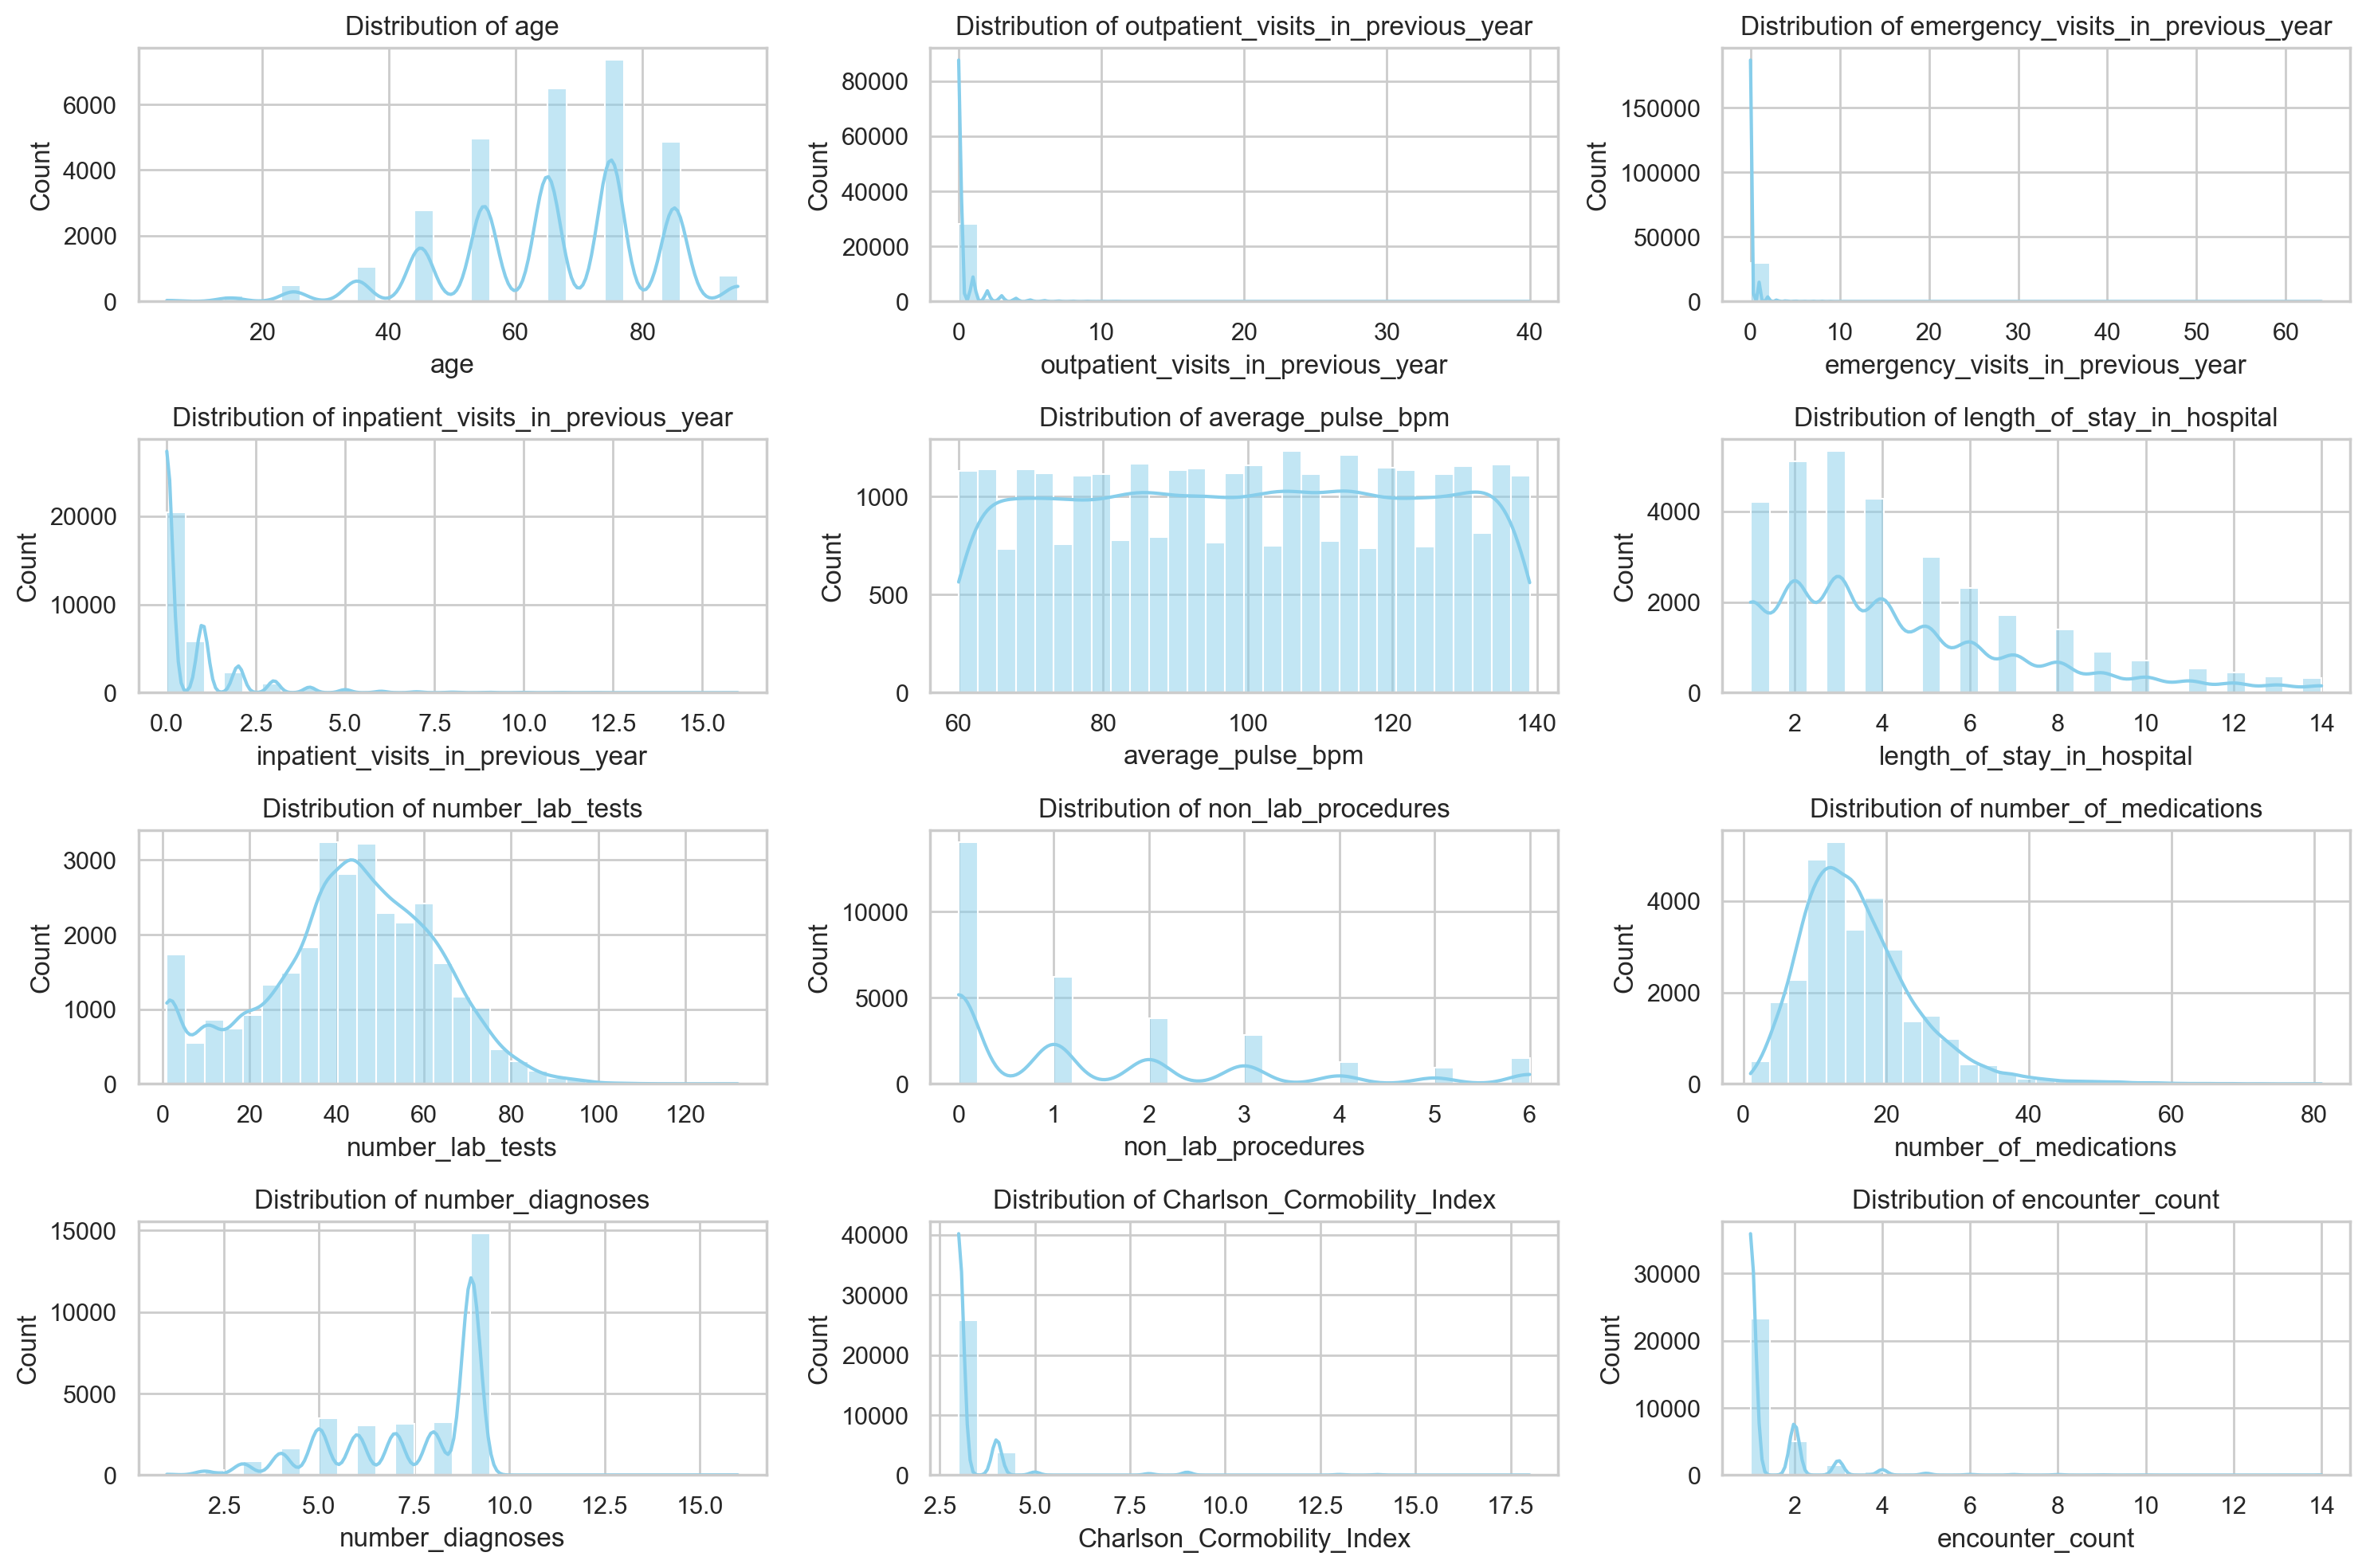

In [75]:
# numeric_variables = [
#     'age', 'outpatient_visits_in_previous_year', 'emergency_visits_in_previous_year',
#     'inpatient_visits_in_previous_year', 'average_pulse_bpm', 'length_of_stay_in_hospital',
#     'number_lab_tests', 'non_lab_procedures', 'number_of_medications', 'number_diagnoses',
#     'Charlson_Cormobility_Index', 'encounter_count'
# ]

# # Plot settings
# plt.figure(figsize=(15, 10))
# sns.set(style="whitegrid")

# for i, variable in enumerate(numeric_variables, 1):
#     plt.subplot(4, 3, i)
#     sns.histplot(data=df_test_encoding, x=variable, kde=True, color='skyblue', bins=30)
#     plt.title(f'Distribution of {variable}')

# # Layout
# plt.tight_layout()

# # Save the figure
# plt.savefig(os.path.join('..', 'figures', 'exp_analysis', 'Numerical_Variables_Distributions.png'), dpi=200)

# plt.show()

<a class="anchor" id="2.3.5-bullet">

### 2.3.5. Scaling
    
</a>

Advantages of Robust Scaler:

Robustness to outliers: Robust Scaler is less sensitive to outliers compared to Min-Max Scaler. It uses the median and interquartile range (IQR) to scale features, making it more robust in the presence of extreme values.
Preserves data distribution: Robust Scaler scales data based on the IQR, preserving the overall distribution of the data while reducing the impact of outliers. This can be beneficial when the dataset contains significant outliers.

In [76]:
X_train_scaler = X_train_encoding.copy()
X_val_scaler = X_val_encoding.copy()

df_test_scaler = df_test_encoding.copy()

In [77]:
# call function
scaler = RobustScaler()

# fit to training data
scaler.fit(X_train_scaler)

# transform the data
X_train_scaler = scaler.transform(X_train_scaler)  
X_val_scaler = scaler.transform(X_val_scaler)  
df_test_scaler = scaler.transform(df_test_scaler) 

# show results
X_train_scaler

array([[ 0.        ,  0.        , -0.5       , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -1.        , ...,  0.        ,
         0.        ,  2.        ],
       [ 0.        ,  0.        ,  1.        , ..., -1.61606105,
         0.        ,  0.        ],
       ...,
       [ 0.        , -1.        , -1.        , ...,  0.        ,
         0.        ,  2.        ],
       [-6.20362186,  0.        ,  1.        , ...,  0.        ,
         0.        ,  2.        ],
       [ 0.        ,  0.        , -3.        , ...,  0.        ,
         0.        ,  0.        ]])

In [78]:
X_train_df_scaler = pd.DataFrame(
    X_train_scaler, columns=X_train.columns).set_index(X_train.index)
X_val_df_scaler = pd.DataFrame(
    X_val_scaler, columns=X_train.columns).set_index(X_val.index)
df_test_df_scaler = pd.DataFrame(
    df_test_scaler, columns=X_train.columns).set_index(df_test.index)


X_train_df_scaler.head()

,race,gender,age,payer_code,outpatient_visits_in_previous_year,emergency_visits_in_previous_year,inpatient_visits_in_previous_year,admission_type,average_pulse_bpm,discharge_disposition,...,non_lab_procedures,number_of_medications,number_diagnoses,glucose_test_result,a1c_test_result,change_in_meds_during_hospitalization,prescribed_diabetes_meds,medication,Charlson_Cormobility_Index,encounter_count
encounter_id,,,,,,,,,,,,,,,,,,,,,
937418,0.0,0.0,-0.5,-1.0,0.0,0.0,3.0,-1.483336,-0.100,0.067456,...,1.5,1.3,0.333333,0.0,0.0,1.0,0.0,0.000000,0.0,0.0
480621,0.0,0.0,-1.0,0.0,0.0,0.0,1.0,0.000000,0.450,0.067456,...,0.0,1.1,0.333333,0.0,0.0,1.0,0.0,0.000000,0.0,2.0
858672,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.000000,-0.500,0.067456,...,-0.5,-0.2,-0.666667,0.0,0.0,0.0,-1.0,-1.616061,0.0,0.0
845093,0.0,0.0,-0.5,-1.0,0.0,0.0,3.0,-0.515390,-0.325,0.000000,...,-0.5,-0.2,0.333333,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
815880,-1.0,0.0,0.0,-1.0,0.0,0.0,2.0,-1.483336,-0.525,0.024930,...,0.5,0.4,-1.000000,0.0,0.0,0.0,0.0,-1.000000,0.0,1.0


<a class="anchor" id="2.3.6-bullet">

### 2.3.6. Fill nan
    
</a>

In [79]:
X_train_knn = X_train_df_scaler.copy()
X_val_knn = X_val_df_scaler.copy()

df_test_knn = df_test_df_scaler.copy()

In [80]:
nans_index = X_train_knn.isna().any(axis=1)
nans_index_val = X_val_knn.isna().any(axis=1)

nans_index_test = df_test_knn.isna().any(axis=1)

In [81]:
imputer = KNNImputer(n_neighbors=5, weights="uniform")

imputer.fit(X_train_knn)

X_train_knn = imputer.transform(X_train_knn)
X_val_knn = imputer.transform(X_val_knn)
df_test_knn = imputer.transform(df_test_knn)

In [82]:
X_train_df_knn = pd.DataFrame(
    X_train_knn, columns=X_train_df_scaler.columns).set_index(X_train_df_scaler.index)
X_val_df_knn = pd.DataFrame(
    X_val_knn, columns=X_train_df_scaler.columns).set_index(X_val_df_scaler.index)
df_test_df_knn = pd.DataFrame(
    df_test_knn, columns=X_train_df_scaler.columns).set_index(df_test_df_scaler.index)

In [83]:
X_train_df_knn.loc[nans_index, numerical_variables]['age']
X_val_df_knn.loc[nans_index_val, numerical_variables]['age']
df_test_df_knn.loc[nans_index_test, numerical_variables]['age']

encounter_id
834256    0.3
435086    0.8
325137   -0.2
683588   -0.2
910978    0.1
         ... 
535140   -0.1
623047    0.2
241330    0.2
890452   -0.4
351214   -0.4
Name: age, Length: 1531, dtype: float64

In [84]:
X_train_df_knn['age'].isna().sum()

0

In [85]:
X_train_under = X_train_df_knn.copy()
y_train_under = y_train.copy()

### Important Note:

##### Even if we are not using the Oversampling or Undersampling (because we disregard it) method we are keepining the name with '_under' since we still keep using the name for the next steps by in any circumstances that doesn't mean that we are using the undersampling method.

<a class="anchor" id="3-bullet">

# 3. Feature Selection
    
</a>

<a class="anchor" id="3.1-bullet">

## 3.1 Univariate analysis
    
</a>

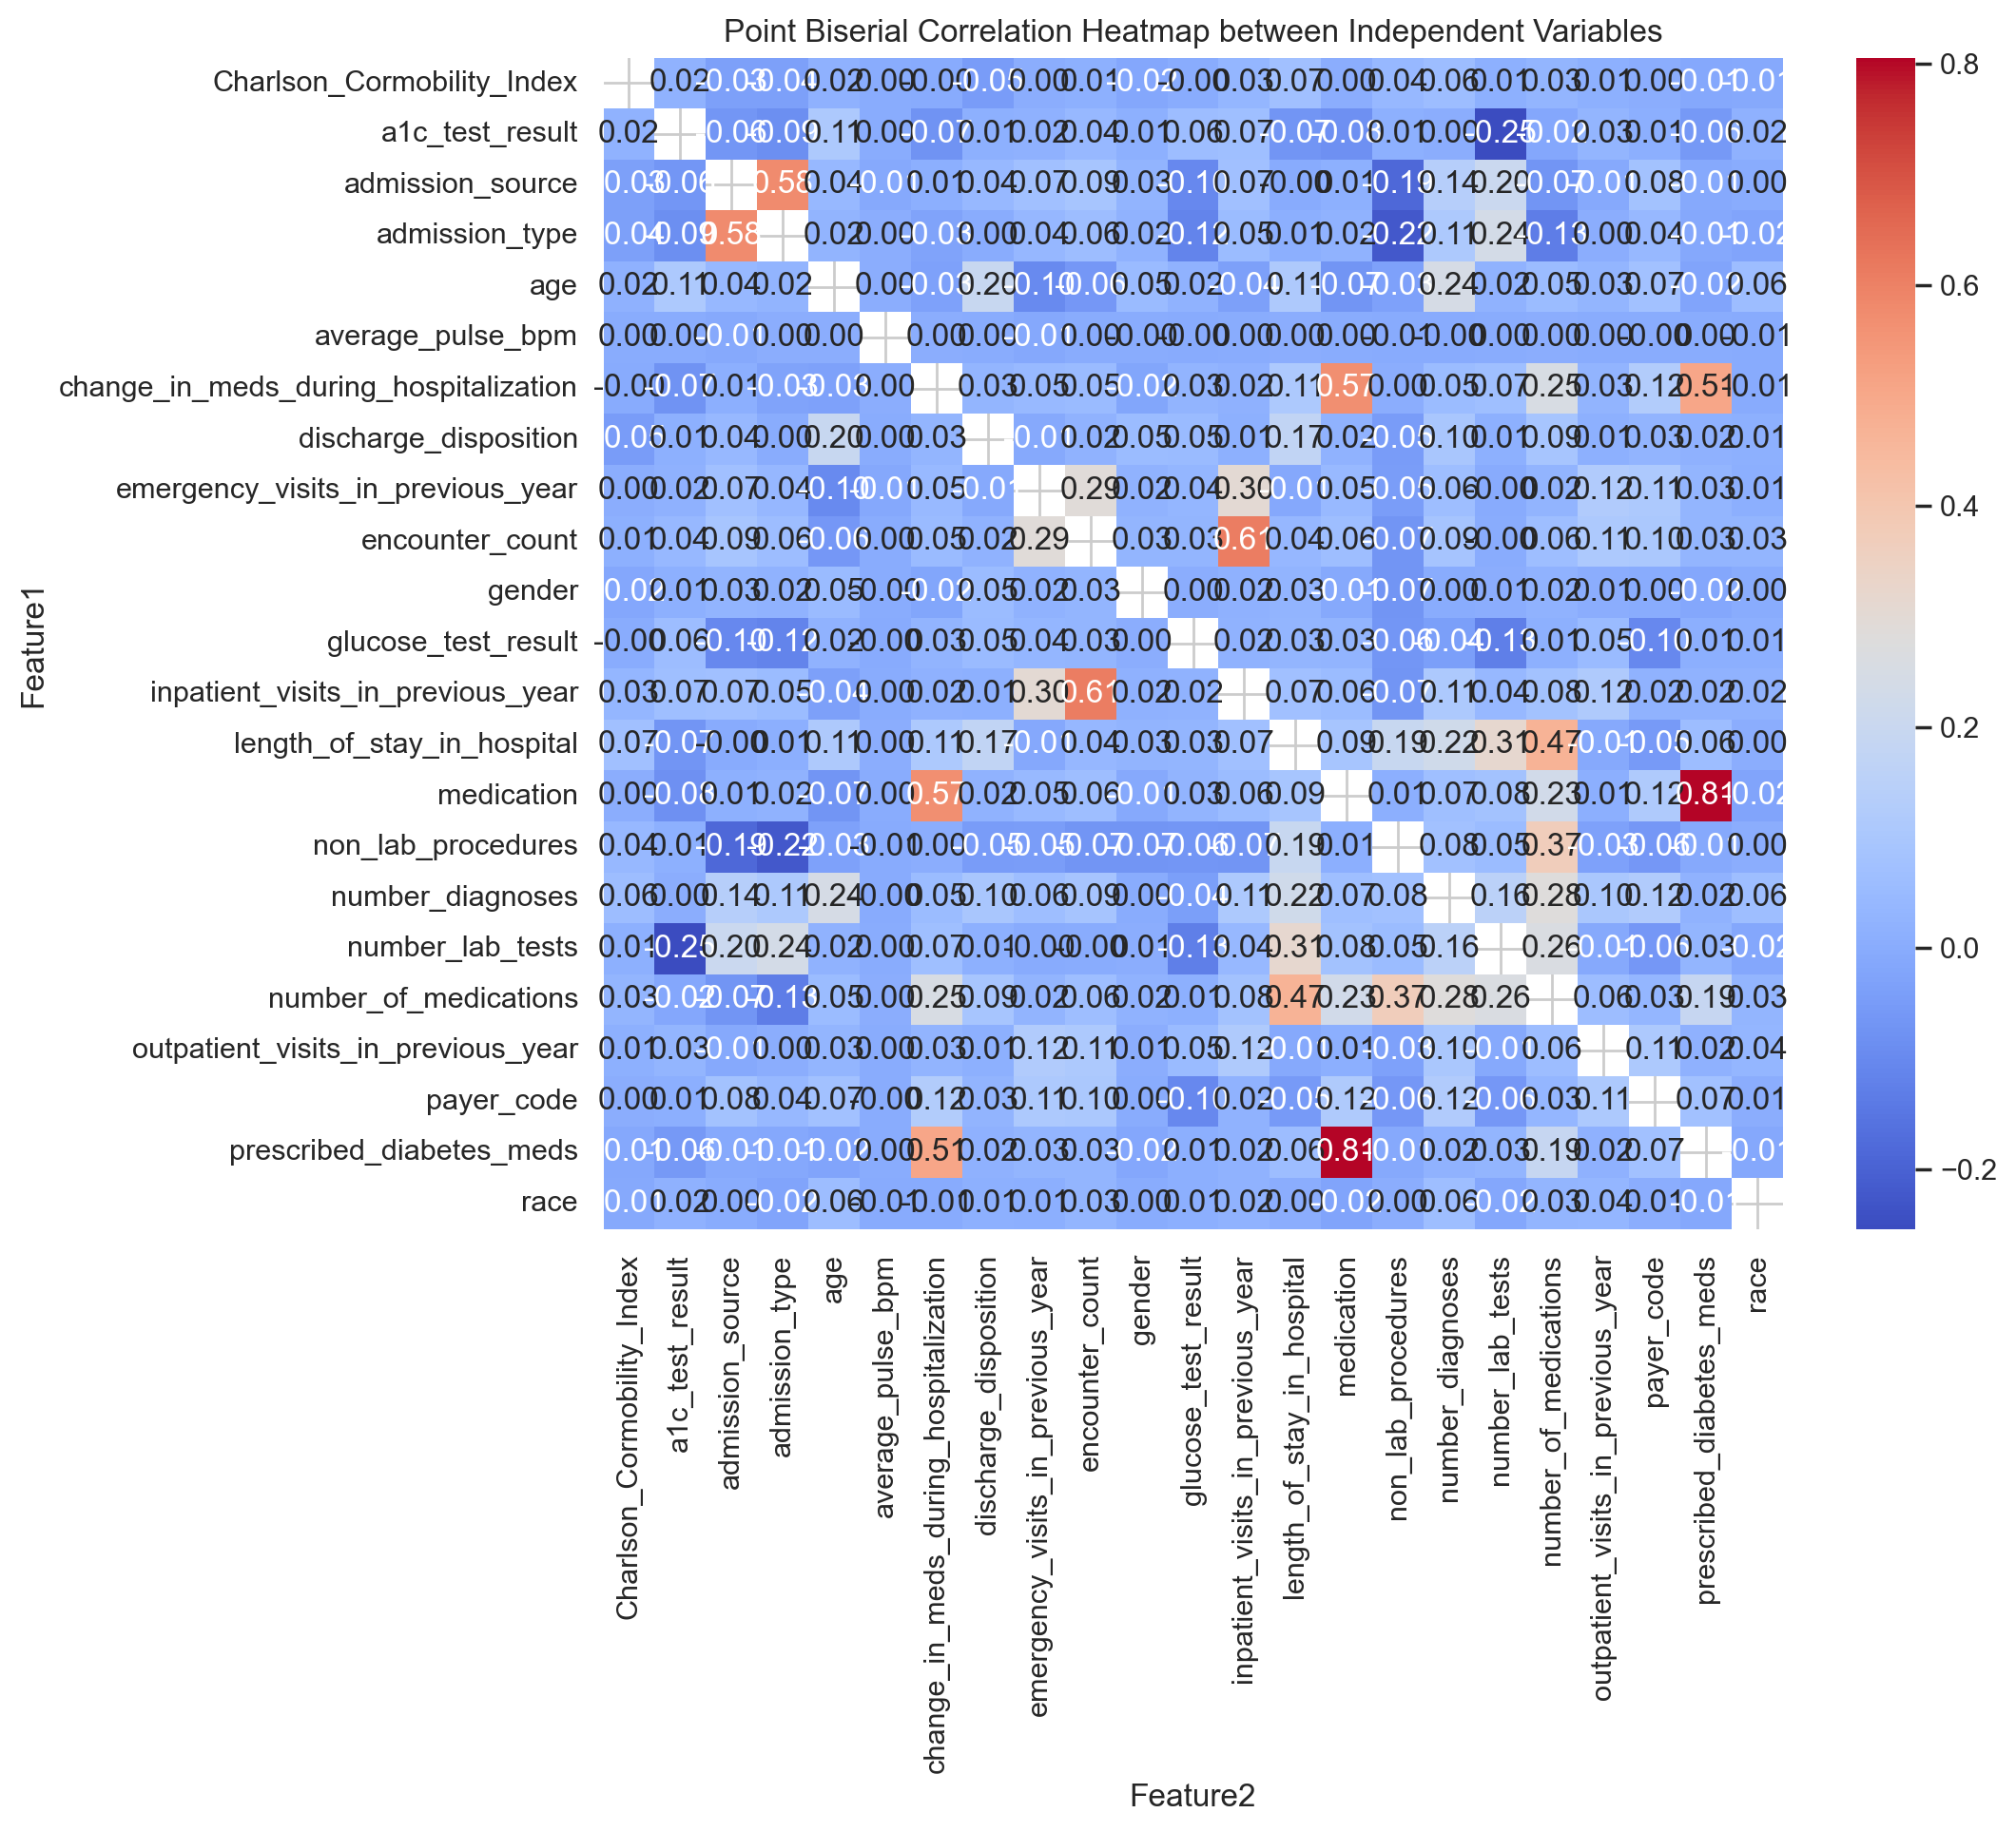

In [86]:
# Calculate point biserial correlation for each pair of features in X_train_under
point_biserial_corr = {}
for column1 in X_train_under.columns:
    for column2 in X_train_under.columns:
        if column1 != column2:
            corr = pointbiserialr(
                X_train_under[column1], X_train_under[column2]).correlation
            point_biserial_corr[(column1, column2)] = corr

# Create a DataFrame to store the correlations
corr_df = pd.DataFrame(list(point_biserial_corr.items()), columns=[
                       'Feature Pair', 'Point Biserial Correlation'])

# Unpack the tuple into separate columns for index and columns
corr_df[['Feature1', 'Feature2']] = pd.DataFrame(
    corr_df['Feature Pair'].tolist(), index=corr_df.index)

# Drop the original 'Feature Pair' column
corr_df = corr_df.drop('Feature Pair', axis=1)

# Reshape data to create a correlation matrix
corr_matrix = corr_df.pivot(
    index='Feature1', columns='Feature2', values='Point Biserial Correlation')

# Create a heatmap using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Point Biserial Correlation Heatmap between Independent Variables')

plt.savefig(os.path.join('..', 'figures', 'exp_analysis', 'Feature_Selection_Binary_Biserial.png'), dpi=200)


plt.show()

<a class="anchor" id="3.2-bullet">

## 3.2 Lasso
    
</a>

In [87]:
def plot_importance(coef, name):
    imp_coef = coef.sort_values()
    plt.figure(figsize=(8, 10))
    imp_coef.plot(kind="barh")
    plt.title("Feature importance using " + name + " Model")

    plt.savefig(os.path.join('..', 'figures', 'exp_analysis',
        'Feature_Selection_Binary_Lasso.png'), dpi=200)
    plt.show()

In [88]:
reg = LassoCV()

In [89]:
reg.fit(X_train_under, y_train_under)

LassoCV()

In [90]:
coef = pd.Series(reg.coef_, index=X_train_under.columns)
coef

race                                     0.001199
gender                                  -0.004130
age                                      0.005197
payer_code                              -0.022602
outpatient_visits_in_previous_year      -0.002493
emergency_visits_in_previous_year        0.004181
inpatient_visits_in_previous_year        0.008438
admission_type                           0.003084
average_pulse_bpm                        0.000510
discharge_disposition                    0.786915
admission_source                        -0.002897
length_of_stay_in_hospital               0.000625
number_lab_tests                         0.001129
non_lab_procedures                      -0.002080
number_of_medications                    0.006664
number_diagnoses                         0.008259
glucose_test_result                     -0.000000
a1c_test_result                          0.000000
change_in_meds_during_hospitalization   -0.002879
prescribed_diabetes_meds                 0.009001


In [91]:
lasso_sorted = coef.sort_values()

In [92]:
non_important_features = coef[abs(coef) < 0.001].index.tolist()

In [93]:
non_important_features

['average_pulse_bpm',
 'length_of_stay_in_hospital',
 'glucose_test_result',
 'a1c_test_result']

In [94]:
# plot_importance(coef, 'Lasso')

<a class="anchor" id="3.3-bullet">

## 3.3 KBest - Mutual Info Classification
    
</a>

In [95]:
X_mic = X_train_under.copy()

In [96]:
# Initialize SelectKBest with the desired scoring function

np.random.seed(42)

# For example, here we use chi-squared (χ²) test for feature selection
k_best = SelectKBest(score_func=mutual_info_classif,
                     k=15)  # Select top k features

# Fit SelectKBest to the data
X_new = k_best.fit_transform(X_mic, y_train_under)

# Get the indices of the selected features
selected_feature_indices = k_best.get_support(indices=True)

# Print the indices of selected features
print("Selected feature indices:", selected_feature_indices)

# Optionally, you can also see the scores of the features
print("Feature scores:", k_best.scores_)

Selected feature indices: [ 0  1  2  3  4  5  6  7  9 15 16 18 19 21 22]
Feature scores: [1.02523241e-03 2.43077193e-03 1.11471598e-03 5.10136170e-03
 7.27536905e-04 1.01797817e-03 1.08739329e-02 6.50697726e-04
 4.59214304e-04 5.13402668e-03 0.00000000e+00 4.83637306e-04
 0.00000000e+00 2.64786156e-04 3.32923326e-04 3.69033376e-03
 8.42897218e-04 0.00000000e+00 4.41497437e-03 3.81055742e-03
 7.07784564e-05 3.79644144e-03 3.17887401e-02]


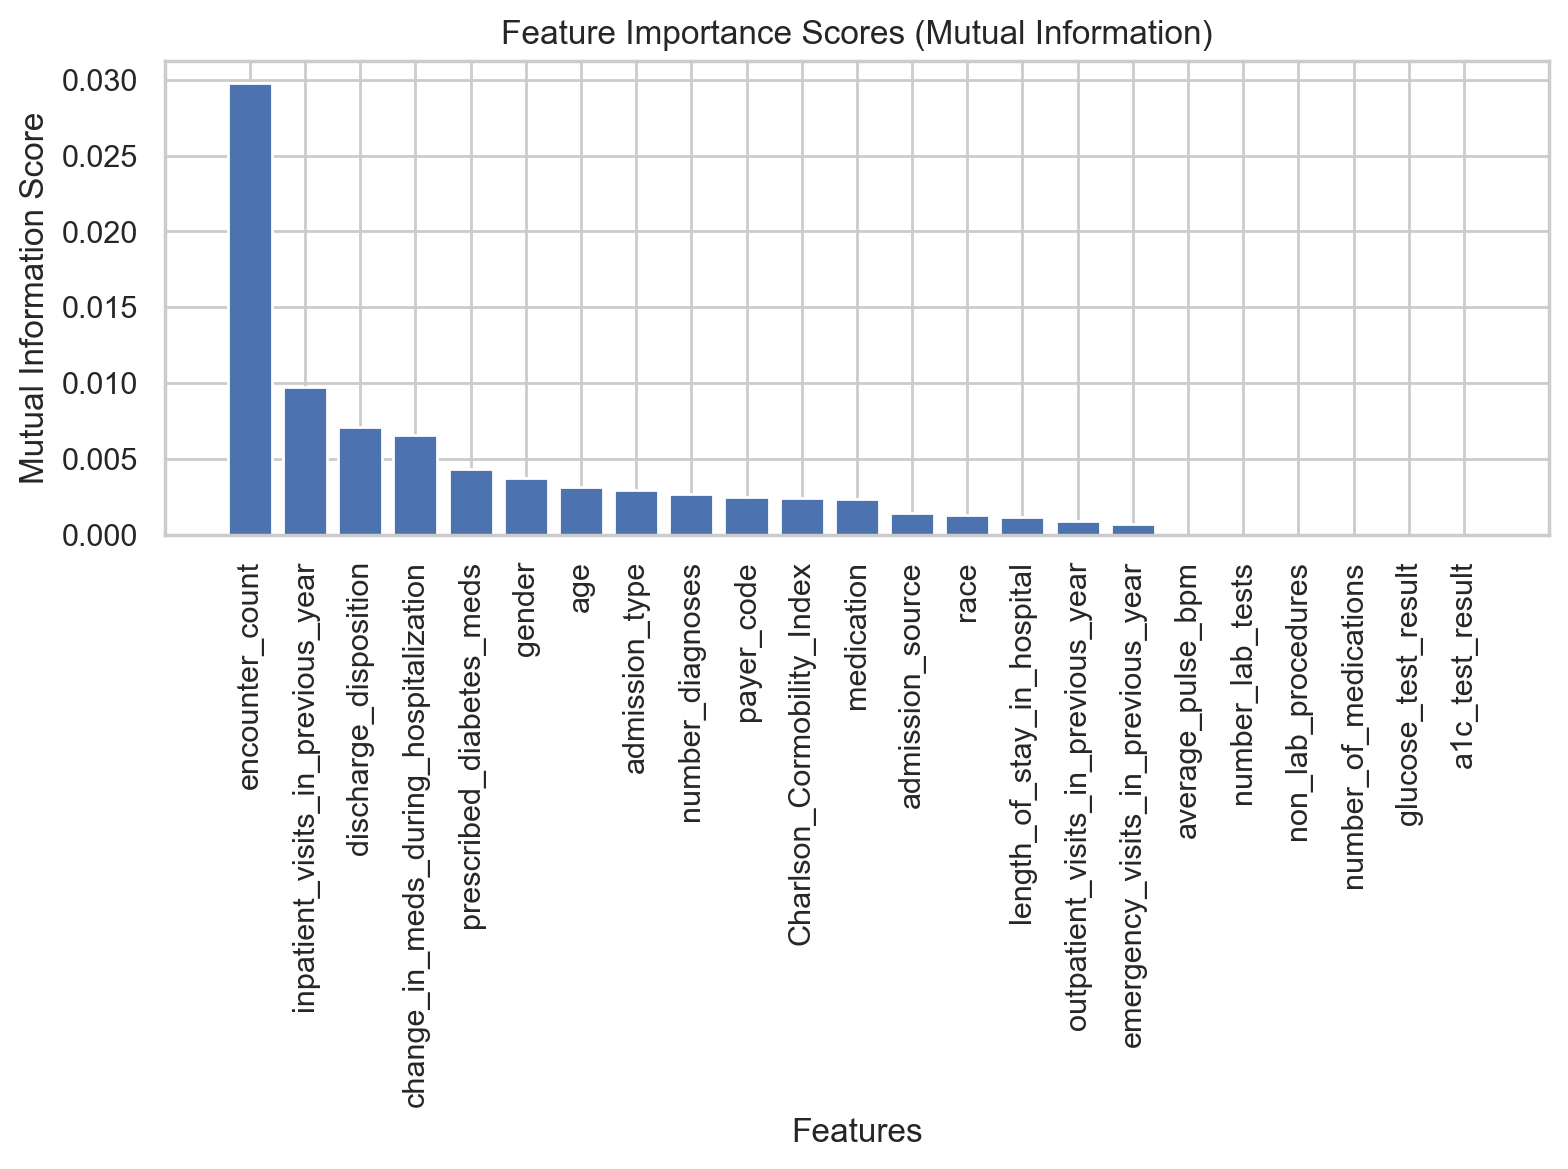

In [97]:
mic_scores = mutual_info_classif(X_mic, y_train_under)

# Sort feature importance scores and corresponding indices
indices = np.argsort(mic_scores)[::-1]
sorted_mic_scores = mic_scores[indices]
sorted_feature_names = X_mic.columns[indices]

# Create a bar plot to visualize feature importance scores
plt.figure(figsize=(8, 6))
bars = plt.bar(range(X.shape[1]), sorted_mic_scores,
               align='center', tick_label=sorted_feature_names)
plt.xticks(rotation='vertical')
plt.xlabel('Features')
plt.ylabel('Mutual Information Score')
plt.title('Feature Importance Scores (Mutual Information)')
plt.tight_layout()

plt.savefig(os.path.join('..', 'figures', 'exp_analysis',
            'Feature_Selection_Binary_MIC.png'), dpi=200)

plt.show()

In [98]:
selected_feature_indices

array([ 0,  1,  2,  3,  4,  5,  6,  7,  9, 15, 16, 18, 19, 21, 22],
      dtype=int64)

<a class="anchor" id="3.4-bullet">

## 3.4 ANOVA
    
</a>

In [99]:
X_anova = X_train_under.copy()

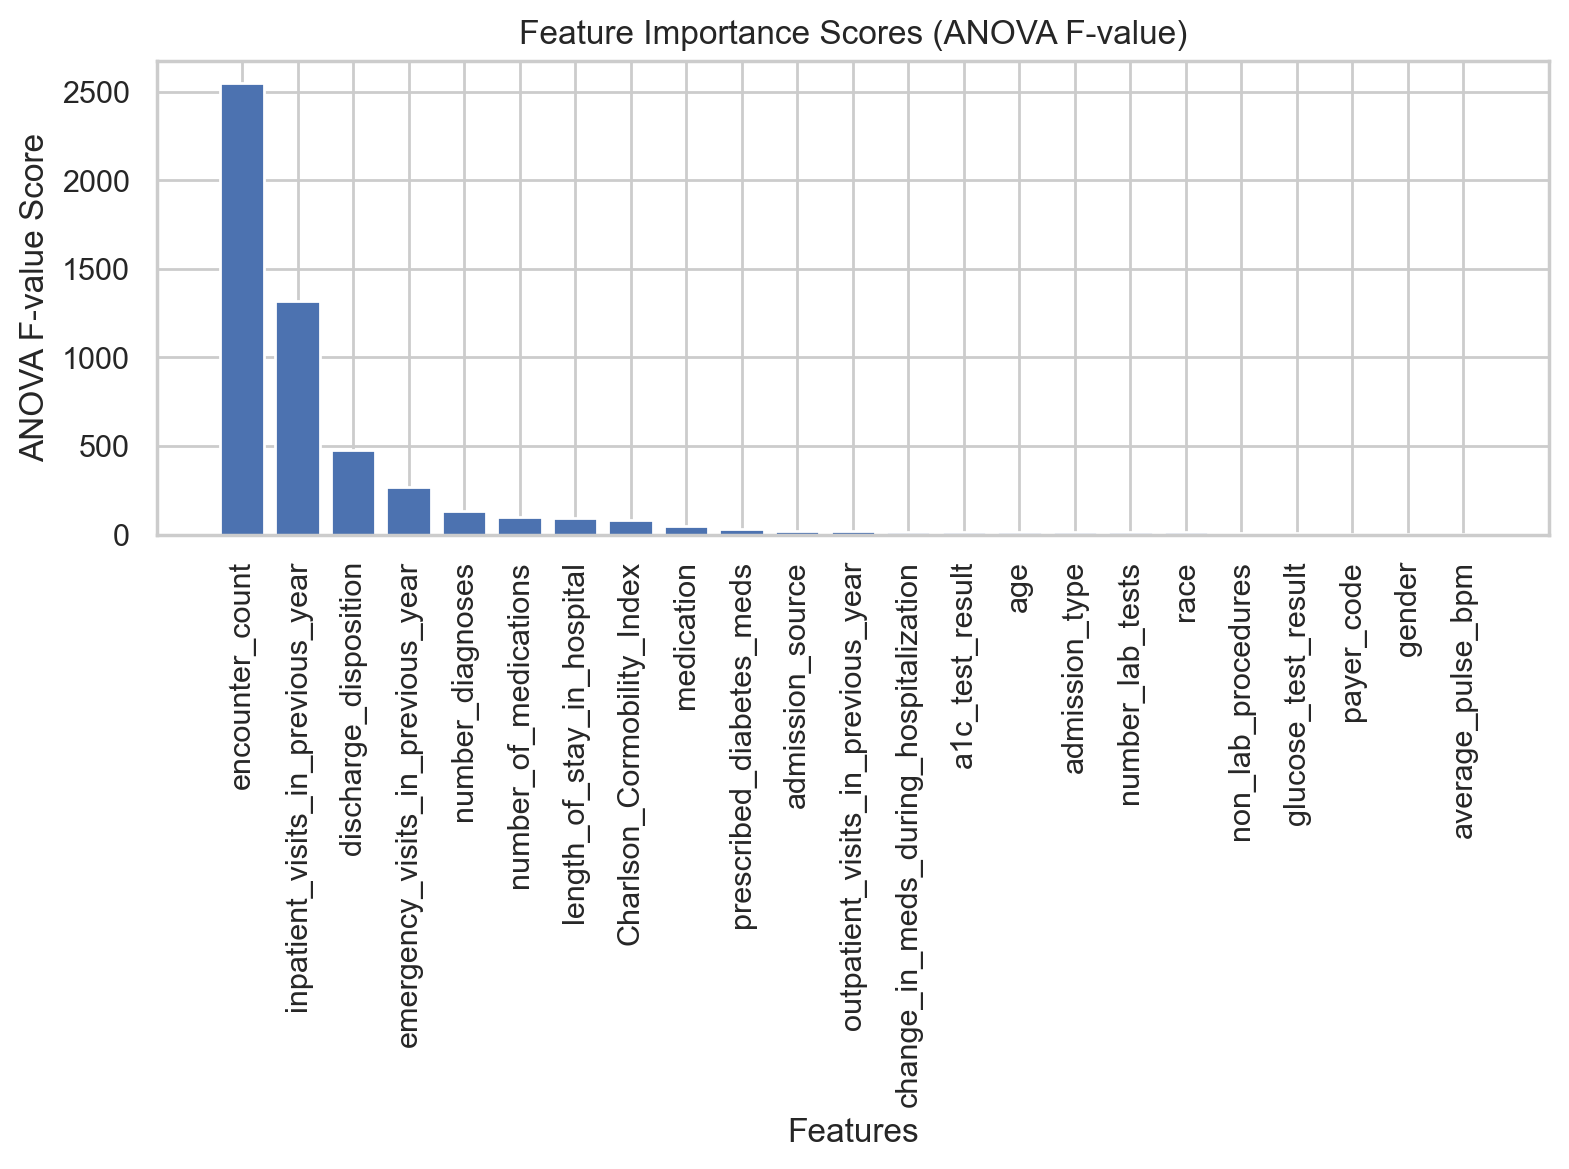

In [100]:
# Compute ANOVA F-value scores for each feature
f_scores, _ = f_classif(X_anova, y_train_under)

# Sort feature importance scores and corresponding indices
indices = np.argsort(f_scores)[::-1]
sorted_f_scores = f_scores[indices]
sorted_feature_names = X_anova.columns[indices]

# Create a bar plot to visualize feature importance scores
plt.figure(figsize=(8, 6))
bars = plt.bar(range(X.shape[1]), sorted_f_scores,
               align='center', tick_label=sorted_feature_names)
plt.xticks(rotation='vertical')
plt.xlabel('Features')
plt.ylabel('ANOVA F-value Score')
plt.title('Feature Importance Scores (ANOVA F-value)')
plt.tight_layout()

plt.savefig(os.path.join('..', 'figures', 'exp_analysis',
            'Feature_Selection_Binary_ANOVA.png'), dpi=200)

plt.show()

<a class="anchor" id="3.5-bullet">

## 3.5 Random Forests
    
</a>

In [101]:
# y_train_under
X_rf = X_train_under.copy()

In [102]:
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the Random Forest model to your data
random_forest.fit(X_rf, y_train_under)

# Get feature importances from the trained model
feature_importances = random_forest.feature_importances_

# Get column names from the feature DataFrame X_rf
column_names = X_rf.columns.tolist()

# Create a dictionary mapping feature importances to column names
importance_dict = {column_names[i]: feature_importances[i]
                   for i in range(len(column_names))}

# Sort feature importances by value in descending order
sorted_importance_dict = dict(
    sorted(importance_dict.items(), key=lambda item: item[1], reverse=True))

# Print feature importances with column names
print("Feature importances:")
for i, (feature_name, importance) in enumerate(sorted_importance_dict.items()):
    print(f"{i + 1}. Feature '{feature_name}': {importance}")

Feature importances:
1. Feature 'average_pulse_bpm': 0.12121969986765908
2. Feature 'number_lab_tests': 0.1183938984836898
3. Feature 'number_of_medications': 0.09939088919774892
4. Feature 'encounter_count': 0.08757794330795504
5. Feature 'length_of_stay_in_hospital': 0.07194048076956698
6. Feature 'age': 0.06334175097324347
7. Feature 'non_lab_procedures': 0.04921849818258208
8. Feature 'number_diagnoses': 0.04695100562890573
9. Feature 'inpatient_visits_in_previous_year': 0.04638675299228183
10. Feature 'admission_type': 0.030947944292873314
11. Feature 'admission_source': 0.03042799708045695
12. Feature 'race': 0.02821197083295106
13. Feature 'outpatient_visits_in_previous_year': 0.02632155468258881
14. Feature 'gender': 0.02369517239465012
15. Feature 'medication': 0.023269868463631025
16. Feature 'discharge_disposition': 0.022118099258003277
17. Feature 'emergency_visits_in_previous_year': 0.019643773745410743
18. Feature 'change_in_meds_during_hospitalization': 0.019254214129625

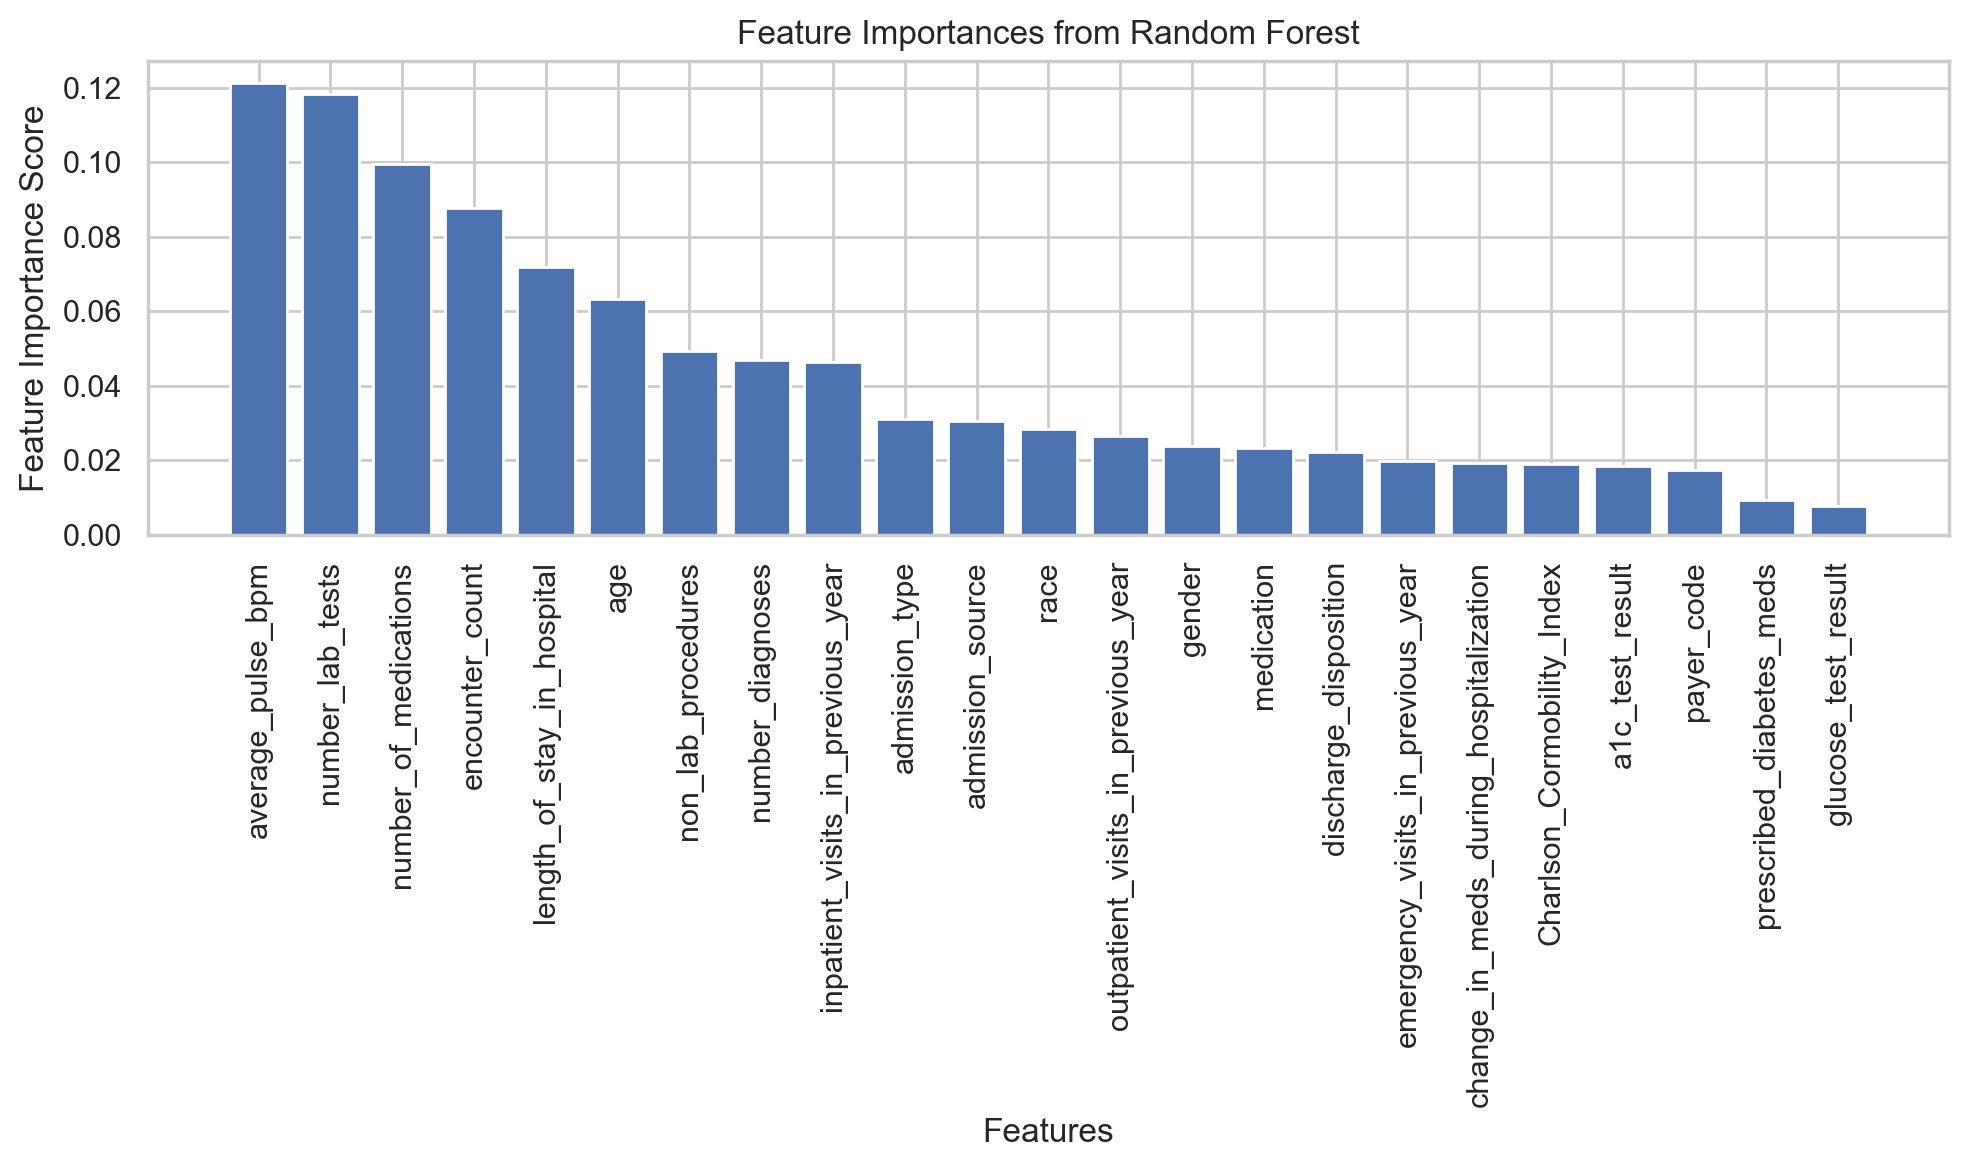

In [103]:
feature_names = list(sorted_importance_dict.keys())
importances = list(sorted_importance_dict.values())

# Create a bar plot to visualize feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances, align='center')
plt.xticks(range(len(importances)), feature_names, rotation='vertical')
plt.xlabel('Features')
plt.ylabel('Feature Importance Score')
plt.title('Feature Importances from Random Forest')
plt.tight_layout()

plt.savefig(os.path.join('..', 'figures', 'exp_analysis',
            'Feature_Selection_Binary_RF.png'), dpi=200)

plt.show()

<a class="anchor" id="3.2.1-bullet">

### 3.2.4 Feature Selection Summary
    
</a>

In [104]:
feature_selection_tests = pd.read_excel('../FeatureSelection.xlsx', sheet_name='FS')
feature_selection_tests

,Variable,Lasso,Point Biserial,Kbest - MIC,ANOVA,Random Forests,Nº True,%True,Decision
0,race,True,True,True,False,True,4,0.8,Keep
1,gender,True,True,True,False,True,4,0.8,Keep
2,age,True,True,True,False,True,4,0.8,Keep
3,payer_code,True,True,True,False,True,4,0.8,Keep
4,outpatient_visits_in_previous_year,True,True,True,True,True,5,1.0,Keep
5,emergency_visits_in_previous_year,True,True,True,True,True,5,1.0,Keep
6,inpatient_visits_in_previous_year,True,True,True,True,True,5,1.0,Keep
7,admission_type,True,True,True,False,True,4,0.8,Keep
8,average_pulse_bpm,True,True,False,False,True,3,0.6,Drop
9,discharge_disposition,True,True,True,True,True,5,1.0,Keep


In [105]:
columns_to_drop = ["average_pulse_bpm", "number_lab_tests",
                   "non_lab_procedures", "glucose_test_result", "a1c_test_result"]

In [106]:
X_train_under

,race,gender,age,payer_code,outpatient_visits_in_previous_year,emergency_visits_in_previous_year,inpatient_visits_in_previous_year,admission_type,average_pulse_bpm,discharge_disposition,...,non_lab_procedures,number_of_medications,number_diagnoses,glucose_test_result,a1c_test_result,change_in_meds_during_hospitalization,prescribed_diabetes_meds,medication,Charlson_Cormobility_Index,encounter_count
encounter_id,,,,,,,,,,,,,,,,,,,,,
937418,0.000000,0.0,-0.5,-1.0,0.0,0.0,3.0,-1.483336,-0.100,0.067456,...,1.5,1.3,0.333333,0.000000,0.0,1.0,0.0,0.000000,0.0,0.0
480621,0.000000,0.0,-1.0,0.0,0.0,0.0,1.0,0.000000,0.450,0.067456,...,0.0,1.1,0.333333,0.000000,0.0,1.0,0.0,0.000000,0.0,2.0
858672,0.000000,0.0,1.0,-1.0,0.0,0.0,0.0,0.000000,-0.500,0.067456,...,-0.5,-0.2,-0.666667,0.000000,0.0,0.0,-1.0,-1.616061,0.0,0.0
845093,0.000000,0.0,-0.5,-1.0,0.0,0.0,3.0,-0.515390,-0.325,0.000000,...,-0.5,-0.2,0.333333,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0
815880,-1.000000,0.0,0.0,-1.0,0.0,0.0,2.0,-1.483336,-0.525,0.024930,...,0.5,0.4,-1.000000,0.000000,0.0,0.0,0.0,-1.000000,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
674248,-1.000000,-1.0,0.5,-1.0,1.0,0.0,0.0,0.000000,0.200,0.000000,...,0.5,-0.7,0.333333,0.000000,0.0,0.0,-1.0,-1.616061,0.0,1.0
712256,-6.203622,-1.0,0.5,0.0,0.0,0.0,0.0,0.000000,0.325,0.000000,...,2.5,-0.3,-0.666667,0.000000,0.0,1.0,0.0,0.000000,0.0,1.0
250558,0.000000,-1.0,-1.0,-1.0,0.0,0.0,5.0,-1.000000,-1.000,-0.082057,...,-0.5,-0.3,-0.666667,0.006203,0.0,0.0,0.0,0.000000,0.0,2.0


In [107]:
X_val_selected = X_val_df_knn.copy()
X_val_selected.drop(columns_to_drop, axis=1, inplace=True)

In [108]:
X_train_selected = X_train_under.copy()
X_train_selected.drop(columns_to_drop, axis=1, inplace=True)

##### Feature selection to df_test

In [109]:
df_test_to_predict = df_test_df_knn.copy()

df_test_to_predict = df_test_to_predict.drop(columns_to_drop, axis=1)

In [110]:
df_test_to_predict.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30530 entries, 499502 to 914270
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   race                                   30530 non-null  float64
 1   gender                                 30530 non-null  float64
 2   age                                    30530 non-null  float64
 3   payer_code                             30530 non-null  float64
 4   outpatient_visits_in_previous_year     30530 non-null  float64
 5   emergency_visits_in_previous_year      30530 non-null  float64
 6   inpatient_visits_in_previous_year      30530 non-null  float64
 7   admission_type                         30530 non-null  float64
 8   discharge_disposition                  30530 non-null  float64
 9   admission_source                       30530 non-null  float64
 10  length_of_stay_in_hospital             30530 non-null  float64
 11  n

In [111]:
X_train_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49865 entries, 937418 to 788870
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   race                                   49865 non-null  float64
 1   gender                                 49865 non-null  float64
 2   age                                    49865 non-null  float64
 3   payer_code                             49865 non-null  float64
 4   outpatient_visits_in_previous_year     49865 non-null  float64
 5   emergency_visits_in_previous_year      49865 non-null  float64
 6   inpatient_visits_in_previous_year      49865 non-null  float64
 7   admission_type                         49865 non-null  float64
 8   discharge_disposition                  49865 non-null  float64
 9   admission_source                       49865 non-null  float64
 10  length_of_stay_in_hospital             49865 non-null  float64
 11  n

<a class="anchor" id="4-bullet">

# 4. Model application/selection
    
</a>

In [112]:
class_weights = {0: 0.11, 1: 0.89}

In [113]:
sample_weights = np.where(y_train_under == 1, 0.89, 0.11)

# Flatten sample_weights if it's a 2D array
sample_weights = sample_weights.flatten()

##### Note: Since the GridSearchCV take a lot of time we let them commented out so that it is not executed.

<a class="anchor" id="4.1-bullet">

## 4.1 Logistic Regression
    
</a>

In [114]:
log_model = LogisticRegression(
    C=0.01, penalty='none', solver='sag', class_weight=class_weights)

In [115]:
log_model.fit(X_train_selected, y_train_under)

LogisticRegression(C=0.01, class_weight={0: 0.11, 1: 0.89}, penalty='none',
                   solver='sag')

In [116]:
y_pred_train_log = log_model.predict(X_train_selected)
y_pred_val_log = log_model.predict(X_val_selected)

In [117]:
# f1_score
print("train: ", f1_score(y_train_under, y_pred_train_log))
print("val: ", f1_score(y_val, y_pred_val_log))

train:  0.3202407973946511
val:  0.32001863281704906


In [118]:
# param_grid = {'penalty': ['l1', 'l2', 'elasticnet', 'none'],
#               'C': [0.01, 0.1, 1, 10, 100, 1000],
#               'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'], }

In [119]:
# grid = GridSearchCV(log_model, param_grid, cv=5, scoring='f1')
# grid.fit(X_train_selected, y_train_under)

In [120]:
# grid_score_log = grid.best_score_
# grid_params_log = grid.best_params_

# print(grid_score_log)
# print(grid_params_log)

In [121]:
log_model_best = LogisticRegression(C=10, penalty='l1', solver='liblinear', class_weight=class_weights)

In [122]:
log_model_best.fit(X_train_selected, y_train_under)

LogisticRegression(C=10, class_weight={0: 0.11, 1: 0.89}, penalty='l1',
                   solver='liblinear')

In [123]:
log_model_best.coef_

array([[ 0.0163047 , -0.0580775 ,  0.0766258 , -0.27976244, -0.01976104,
         0.04347822,  0.0743791 ,  0.05180248, 10.3952494 , -0.02500746,
         0.01546265,  0.05156964,  0.11527327, -0.03802474,  0.15860035,
         0.0350155 ,  0.10645015,  0.34932537]])

In [124]:
y_pred_train_log_best = log_model_best.predict(X_train_selected)
y_pred_val_log_best = log_model_best.predict(X_val_selected)

In [125]:
print("train: ", f1_score(y_train_under, y_pred_train_log_best))
print("val: ", f1_score(y_val, y_pred_val_log_best))

train:  0.3120293847566575
val:  0.3129721562702353


<a class="anchor" id="4.2-bullet">

## 4.2 Gaussian Naive Bayes
    
</a>

Gaussian Naive Bayes is a simple and efficient classifier suitable for certain types of datasets, especially when dealing with continuous features that follow a Gaussian distribution and in scenarios with limited training data.

In [126]:
modelNB = GaussianNB(priors=None, var_smoothing=2.848035868435799e-07)

In [127]:
modelNB.fit(X=X_train_selected, y=y_train_under)

GaussianNB(var_smoothing=2.848035868435799e-07)

In [128]:
y_pred_train_nb = modelNB.predict(X_train_selected)
y_pred_val_nb = modelNB.predict(X_val_selected)

In [129]:
print("train: ", modelNB.score(X_train_selected, y_train_under))
print("val: ", modelNB.score(X_val_selected, y_val))

train:  0.8462047528326482
val:  0.847644003556221


In [130]:
modelNB.score(X_val_selected, y_val)

0.847644003556221

In [131]:
print("train: ", f1_score(y_train_under, y_pred_train_nb))
print("val: ", f1_score(y_val, y_pred_val_nb))

train:  0.21800754563067196
val:  0.22030651340996169


<a class="anchor" id="4.3-bullet">

## 4.3 Instance Based Learning (KNN)
    
</a>

In [132]:
modelKNN = KNeighborsClassifier(
    algorithm='auto', metric='euclidean', n_neighbors=19, weights='distance')

In [133]:
modelKNN.fit(X_train_selected, y_train_under)

KNeighborsClassifier(metric='euclidean', n_neighbors=19, weights='distance')

In [134]:
y_pred_train_knn = modelKNN.predict(X_train_selected)
y_pred_val_knn = modelKNN.predict(X_val_selected)

In [135]:
print(modelKNN.score(X_train_selected, y_train_under))
print(modelKNN.score(X_val_selected, y_val))

0.9992178882984057
0.887370736044172


In [136]:
modelKNN.kneighbors(X=X_val_selected)

(array([[0.59753689, 0.66193765, 0.67363834, ..., 0.96341136, 0.98322849,
         1.02654206],
        [0.42849867, 0.42849867, 0.42922329, ..., 0.59523815, 0.60144213,
         0.6096988 ],
        [0.39051248, 1.00498756, 1.27910676, ..., 1.82002747, 1.82497419,
         1.83590054],
        ...,
        [0.43377581, 0.46707756, 0.51434457, ..., 0.85916496, 0.86549671,
         0.88071644],
        [0.34801022, 0.61291227, 1.03561576, ..., 1.197335  , 1.19923369,
         1.19923369],
        [0.68239391, 0.71666667, 0.9665571 , ..., 1.28495568, 1.29278328,
         1.29368122]]),
 array([[27852,  7493, 43211, ..., 24476, 25159, 21904],
        [19982, 14188,  5772, ..., 48346, 41532, 21317],
        [43421, 16423, 11925, ..., 37542, 15548, 18298],
        ...,
        [ 1412, 47341,  9602, ..., 19053, 10142, 20040],
        [47814,  2326, 12664, ..., 24365,  1298, 15873],
        [18749, 12034,  6456, ..., 27619, 38594, 43494]], dtype=int64))

In [137]:
# precision
precision = precision_score(y_train_under, y_pred_train_knn)
print(f'Precision: {precision:.4f}')

Precision: 1.0000


In [138]:
# recall
recall = recall_score(y_train_under, y_pred_train_knn)
print(f'Recall: {recall:.4f}')

Recall: 0.9930


In [139]:
print("train: ", f1_score(y_train_under, y_pred_train_knn))
print("val: ", f1_score(y_val, y_pred_val_knn))

train:  0.9964836353800379
val:  0.03912175648702595


<a class="anchor" id="4.4-bullet">

## 4.4 Neural Networks
    
</a>

In [140]:
modelmlp = MLPClassifier().fit(X_train_selected, y_train_under)

In [141]:
y_pred_train_nn = modelmlp.predict(X_train_selected)
y_pred_val_nn = modelmlp.predict(X_val_selected)

In [142]:
# precision
precision = precision_score(y_val, y_pred_val_nn)
print(f'Precision: {precision:.4f}')

Precision: 0.3520


In [143]:
# recall
recall = recall_score(y_val, y_pred_val_nn)
print(f'Recall: {recall:.4f}')

Recall: 0.0948


In [144]:
print("train: ", f1_score(y_train_under, y_pred_train_nn))
print('val:', f1_score(y_val, y_pred_val_nn))

train:  0.2239774330042313
val: 0.14932276181037332


<a class="anchor" id="4.5-bullet">

## 4.5 Decision Trees
    
</a>

In [145]:
modeldt = DecisionTreeClassifier(class_weight=class_weights, random_state = 0)

In [146]:
modeldt.fit(X_train_selected, y_train_under)

DecisionTreeClassifier(class_weight={0: 0.11, 1: 0.89}, random_state=0)

In [147]:
y_pred_train_dt = modeldt.predict(X_train_selected)
y_pred_val_dt = modeldt.predict(X_val_selected)

In [148]:
# recall
recall = recall_score(y_val, y_pred_val_dt)
print(f'Recall: {recall:.4f}')

Recall: 0.2029


In [149]:
# precision
precision = precision_score(y_val, y_pred_val_dt)
print(f'Precision: {precision:.4f}')

Precision: 0.2027


In [150]:
print("train: ", f1_score(y_train_under, y_pred_train_dt))
print('val:', f1_score(y_val, y_pred_val_dt))

train:  0.9965081923180231
val: 0.2028074586214121


In [151]:
# param_grid = {
#     'criterion': ['gini', 'entropy'],
#     'splitter': ['best', 'random'],
#     'max_depth': [None, 2, 10, 15, 20],
#     'max_leaf_nodes': [None, 10, 20, 50],
#     'min_samples_split': [10, 200, 500],
#     'min_samples_leaf': [100, 500],
#     'min_impurity_decrease': [0, 0.1, 0.2]
# }

In [152]:
# grid = GridSearchCV(estimator=modeldt, param_grid=param_grid,
#                     n_jobs=-1, cv=5, scoring='f1')

In [153]:
# grid_result = grid.fit(X_train_selected, y_train_under)

In [154]:
# print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

In [155]:
modeldt_best = DecisionTreeClassifier(
    criterion='entropy', splitter='random', max_depth=20, max_leaf_nodes=20, min_samples_split=200, min_samples_leaf=50, min_impurity_decrease=0, class_weight=class_weights, random_state = 0
).fit(X_train_selected, y_train_under)

In [156]:
y_pred_train_dt_best = modeldt_best.predict(X_train_selected)
y_pred_val_dt_best = modeldt_best.predict(X_val_selected)

In [157]:
print("train: ", f1_score(y_train_under, y_pred_train_dt_best))
print('val:', f1_score(y_val, y_pred_val_dt_best))

train:  0.32551994127722045
val: 0.3253588516746412


<a class="anchor" id="4.6-bullet">

## 4.6 Random Forests
    
</a>

In [158]:
modelrf = RandomForestClassifier(random_state=0)

In [159]:
modelrf.fit(X_train_selected, y_train_under)

RandomForestClassifier(random_state=0)

In [160]:
y_pred_train_rf = modelrf.predict(X_train_selected)
y_pred_val_rf = modelrf.predict(X_val_selected)

In [161]:
# recall
recall = recall_score(y_val, y_pred_val_rf)
print(f'Recall: {recall:.4f}')

Recall: 0.0373


In [162]:
precision = precision_score(y_val, y_pred_val_rf)
print(f'Precision: {precision:.4f}')

Precision: 0.4083


In [163]:
print("train: ", f1_score(y_train_under, y_pred_train_rf))
print('val:', f1_score(y_val, y_pred_val_rf))

train:  0.9963970455773734
val: 0.06838263542066846


In [164]:
# param_grid = {
#     'bootstrap': [True, False],
#     'max_depth': [80, 90, 100],  # 150
#     'max_features': ['auto', 'sqrt'],
#     'min_samples_leaf': [2, 3, 4],  # 5
#     'min_samples_split': [5, 10],  # 12
#     'n_estimators': [5, 20, 50]  # 75, 100
# }

In [165]:
# grid = GridSearchCV(estimator=modelrf, param_grid=param_grid,
#                     scoring='f1', n_jobs=-1, cv=5)

In [166]:
# grid_result = grid.fit(X_train_selected, y_train_under)

In [167]:
# print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

In [168]:
modelrf_best = RandomForestClassifier(
    bootstrap=False, max_depth=6, max_features='sqrt', min_samples_leaf=2, min_samples_split=5, n_estimators=400, class_weight='balanced', random_state=0
)

In [169]:
modelrf_best.fit(X_train_selected, y_train_under)

RandomForestClassifier(bootstrap=False, class_weight='balanced', max_depth=6,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=400, random_state=0)

In [170]:
y_pred_train_rf_best = modelrf_best.predict(X_train_selected)
y_pred_val_rf_best = modelrf_best.predict(X_val_selected)

In [171]:
precision = precision_score(y_val, y_pred_val_rf_best)
print("Precision:", precision)

recall = recall_score(y_val, y_pred_val_rf_best)
print("recall:", recall)
print("train: ", f1_score(y_train_under, y_pred_train_rf_best))
print('val:', f1_score(y_val, y_pred_val_rf_best))

Precision: 0.20526918671248567
recall: 0.7513626834381552
train:  0.32662347678543885
val: 0.32244714349977505


<a class="anchor" id="4.7-bullet">

## 4.7 Adaboost
    
</a>

In [172]:
model_ab = AdaBoostClassifier(learning_rate=1.5, n_estimators=200)

In [173]:
model_ab.fit(X_train_selected, y_train_under, sample_weight=sample_weights)

AdaBoostClassifier(learning_rate=1.5, n_estimators=200)

In [174]:
y_pred_train = model_ab.predict(X_train_selected)
y_pred_val = model_ab.predict(X_val_selected)

In [175]:
precision = precision_score(y_val, y_pred_val)
print("Precision:", precision)

Precision: 0.21056632459141011


In [176]:
recall = recall_score(y_val, y_pred_val)
print("recall:", recall)

recall: 0.6968553459119496


In [177]:
print("train: ", f1_score(y_train_under, y_pred_train))
print('val:', f1_score(y_val, y_pred_val))

train:  0.32414078674948243
val: 0.3234092235843549


In [178]:
conf_matrix_ab = confusion_matrix(y_val, y_pred_val)
conf_matrix_ab

array([[12755,  6231],
       [  723,  1662]], dtype=int64)

#### AdaBoost Grid Search

In [179]:
parameters = {
    'n_estimators': [180, 200, 220],
    'learning_rate': [1, 1.5, 1.8],
}

In [180]:
grid = GridSearchCV(model_ab, parameters, scoring='f1', cv=5)

In [181]:
grid.fit(X_train_selected, y_train_under)

GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(learning_rate=1.5, n_estimators=200),
             param_grid={'learning_rate': [1, 1.5, 1.8],
                         'n_estimators': [180, 200, 220]},
             scoring='f1')

In [182]:
best_params = grid.best_params_
best_model = grid.best_estimator_
print(grid.best_params_)
print(grid.best_estimator_)

{'learning_rate': 1.5, 'n_estimators': 200}
AdaBoostClassifier(learning_rate=1.5, n_estimators=200)


<a class="anchor" id="4.8-bullet">

## 4.8 Gradient Boost
    
</a>

In [183]:
gradient_boost = GradientBoostingClassifier(
    learning_rate=0.2, n_estimators=200, max_depth=2)

In [184]:
gradient_boost.fit(X_train_selected, y_train_under,
                   sample_weight=sample_weights)

GradientBoostingClassifier(learning_rate=0.2, max_depth=2, n_estimators=200)

In [185]:
y_pred_train = gradient_boost.predict(X_train_selected)
y_pred_val = gradient_boost.predict(X_val_selected)

precision = precision_score(y_val, y_pred_val)
print("Precision:", precision)

recall = recall_score(y_val, y_pred_val)
print("recall:", recall)

print("train: ", f1_score(y_train_under, y_pred_train))
print('val:', f1_score(y_val, y_pred_val))

Precision: 0.21328087744396756
recall: 0.750104821802935
train:  0.33564109664912767
val: 0.33212661282836725


In [186]:
conf_matrix_gb = confusion_matrix(y_val, y_pred_val)
conf_matrix_gb

array([[12387,  6599],
       [  596,  1789]], dtype=int64)

In [187]:
reportgb = classification_report(y_train_under, y_pred_train)
print(reportgb)

              precision    recall  f1-score   support

           0       0.96      0.65      0.77     44300
           1       0.22      0.76      0.34      5565

    accuracy                           0.66     49865
   macro avg       0.59      0.71      0.56     49865
weighted avg       0.87      0.66      0.73     49865



In [188]:
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of boosting stages to be used
    'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage used in update
    # 'max_depth': [3, 5, 7],
}

In [189]:
grid = GridSearchCV(gradient_boost, param_grid, scoring='f1', cv=5)

In [190]:
grid.fit(X_train_selected, y_train_under)

GridSearchCV(cv=5,
             estimator=GradientBoostingClassifier(learning_rate=0.2,
                                                  max_depth=2,
                                                  n_estimators=200),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [191]:
best_params = grid.best_params_
best_model = grid.best_estimator_
print(grid.best_params_)
print(grid.best_estimator_)

{'learning_rate': 0.2, 'n_estimators': 200}
GradientBoostingClassifier(learning_rate=0.2, max_depth=2, n_estimators=200)


<a class="anchor" id="4.9-bullet">

## 4.9 Support Vector Machines
    
</a>

In [192]:
model_svm = SVC(class_weight=class_weights)
model_svm.fit(X_train_selected, y_train_under)

y_pred_train = model_svm.predict(X_train_selected)
y_pred_val = model_svm.predict(X_val_selected)

precision = precision_score(y_val, y_pred_val)
print("Precision:", precision)

recall = recall_score(y_val, y_pred_val)
print("recall:", recall)

print("train: ", f1_score(y_train_under, y_pred_train))
print('val:', f1_score(y_val, y_pred_val))

Precision: 0.204412794770021
recall: 0.7341719077568134
train:  0.32082338668649474
val: 0.3197881472011689


In [193]:
# param_grid_svc = {
#     'C': [0.1, 1, 10],
#     'kernel': ['linear', 'rbf'],
#     'gamma': ['scale', 'auto']
#     }

In [194]:
# grid = GridSearchCV(model_svm, param_grid_svc, scoring='f1', cv=5)

In [195]:
# grid.fit(X_train_selected, y_train_under)

In [196]:
# best_params = grid.best_params_
# best_model = grid.best_estimator_
# print(grid.best_params_)
# print(grid.best_estimator_)

In [197]:
modelsvm_best = SVC(C=1, gamma='scale', kernel='linear', class_weight={0: 0.11, 1: 0.89})

modelsvm_best.fit(X_train_selected, y_train_under)

y_pred_train_svm_best = modelsvm_best.predict(X_train_selected)
y_pred_val_svm_best = modelsvm_best.predict(X_val_selected)

precision = precision_score(y_val, y_pred_val)
recall = recall_score(y_val, y_pred_val)
train = f1_score(y_train_under, y_pred_train)
val = f1_score(y_val, y_pred_val)

print("Precision:", precision)
print("Recall:", recall)
print("Train:", train)
print("Val:", val)

Precision: 0.204412794770021
Recall: 0.7341719077568134
Train: 0.32082338668649474
Val: 0.3197881472011689


<a class="anchor" id="4.10-bullet">

## 4.10 Stacking
    
</a>

In [198]:
# #best models
# ab = AdaBoostClassifier(learning_rate=1.5, n_estimators=200).fit(X_train_selected, y_train_under,sample_weight=sample_weights)
# gb = GradientBoostingClassifier(learning_rate=0.2, n_estimators=200, max_depth=2).fit(X_train_selected, y_train_under,sample_weight=sample_weights),
# rf = RandomForestClassifier(bootstrap=False, max_depth=6, max_features='sqrt', min_samples_leaf=2, min_samples_split=5, n_estimators=400, class_weight='balanced').fit(X_train_selected, y_train_under)

In [199]:
estimators = [('ab',AdaBoostClassifier(learning_rate=1.5, n_estimators=200).fit(X_train_selected, y_train_under,sample_weight=sample_weights)),
              ('gb',GradientBoostingClassifier(learning_rate=0.2, n_estimators=200, max_depth=2).fit(X_train_selected, y_train_under,sample_weight=sample_weights))]

In [200]:
st = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(class_weight=class_weights)).fit(X_train_selected, y_train_under)


In [201]:
y_pred_train = st.predict(X_train_selected)
y_pred_val = st.predict(X_val_selected)

precision = precision_score(y_val, y_pred_val)
print("Precision:", precision)

recall = recall_score(y_val, y_pred_val)
print("recall:", recall)

print("train: ", f1_score(y_train_under, y_pred_train))
print('val:', f1_score(y_val, y_pred_val))

Precision: 0.23280500218118366
recall: 0.6712788259958071
train:  0.3530769585891695
val: 0.34571366875404885


In [202]:
conf_matrix_stacking = confusion_matrix(y_val, y_pred_val)
conf_matrix_stacking

array([[13710,  5276],
       [  784,  1601]], dtype=int64)

In [203]:
df_test_to_predict_stacking = df_test_to_predict.copy()
df_test_to_predict_stacking

,race,gender,age,payer_code,outpatient_visits_in_previous_year,emergency_visits_in_previous_year,inpatient_visits_in_previous_year,admission_type,discharge_disposition,admission_source,length_of_stay_in_hospital,number_of_medications,number_diagnoses,change_in_meds_during_hospitalization,prescribed_diabetes_meds,medication,Charlson_Cormobility_Index,encounter_count
encounter_id,,,,,,,,,,,,,,,,,,
499502,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,-0.25,-0.1,-0.666667,0.0,0.0,-1.000000,0.0,0.0
447319,0.0,-1.0,-2.0,0.0,0.0,0.0,1.0,0.000000,0.000000,0.0,1.50,-0.8,-0.333333,0.0,-1.0,-1.616061,0.0,1.0
309126,-1.0,-1.0,-1.5,-1.0,0.0,0.0,0.0,0.000000,0.000000,0.0,-0.50,-0.3,-0.666667,0.0,0.0,0.000000,1.0,0.0
181183,0.0,-1.0,-0.5,0.0,0.0,0.0,0.0,-1.000000,0.000000,0.0,0.00,0.1,0.333333,1.0,0.0,0.000000,0.0,0.0
359339,0.0,-1.0,0.0,-1.0,0.0,0.0,0.0,0.000000,0.000000,0.0,-0.75,-0.5,0.333333,0.0,0.0,-1.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451150,0.0,-1.0,0.5,0.0,0.0,0.0,0.0,0.000000,0.067456,0.0,0.00,-0.4,0.333333,0.0,-1.0,-1.616061,0.0,0.0
549298,0.0,-1.0,0.0,-1.0,0.0,0.0,4.0,0.000000,0.000000,0.0,-0.50,0.4,0.333333,0.0,0.0,0.000000,0.0,1.0
327586,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.000000,0.067456,0.0,-0.50,0.7,-0.666667,0.0,0.0,0.000000,0.0,0.0


In [204]:
y_pred_test_stacking = st.predict(df_test_to_predict_stacking)
y_pred_test_stacking

array([0, 0, 0, ..., 0, 0, 0])

In [205]:
df_test_to_predict_stacking['readmitted_binary_bool'] = y_pred_test_stacking
df_test_to_predict_stacking['readmitted_binary'] = np.where(
    df_test_to_predict_stacking['readmitted_binary_bool'] == 1, "Yes", "No")
df_test_to_predict_stacking

,race,gender,age,payer_code,outpatient_visits_in_previous_year,emergency_visits_in_previous_year,inpatient_visits_in_previous_year,admission_type,discharge_disposition,admission_source,length_of_stay_in_hospital,number_of_medications,number_diagnoses,change_in_meds_during_hospitalization,prescribed_diabetes_meds,medication,Charlson_Cormobility_Index,encounter_count,readmitted_binary_bool,readmitted_binary
encounter_id,,,,,,,,,,,,,,,,,,,,
499502,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,-0.25,-0.1,-0.666667,0.0,0.0,-1.000000,0.0,0.0,0,No
447319,0.0,-1.0,-2.0,0.0,0.0,0.0,1.0,0.000000,0.000000,0.0,1.50,-0.8,-0.333333,0.0,-1.0,-1.616061,0.0,1.0,0,No
309126,-1.0,-1.0,-1.5,-1.0,0.0,0.0,0.0,0.000000,0.000000,0.0,-0.50,-0.3,-0.666667,0.0,0.0,0.000000,1.0,0.0,0,No
181183,0.0,-1.0,-0.5,0.0,0.0,0.0,0.0,-1.000000,0.000000,0.0,0.00,0.1,0.333333,1.0,0.0,0.000000,0.0,0.0,0,No
359339,0.0,-1.0,0.0,-1.0,0.0,0.0,0.0,0.000000,0.000000,0.0,-0.75,-0.5,0.333333,0.0,0.0,-1.000000,0.0,0.0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451150,0.0,-1.0,0.5,0.0,0.0,0.0,0.0,0.000000,0.067456,0.0,0.00,-0.4,0.333333,0.0,-1.0,-1.616061,0.0,0.0,0,No
549298,0.0,-1.0,0.0,-1.0,0.0,0.0,4.0,0.000000,0.000000,0.0,-0.50,0.4,0.333333,0.0,0.0,0.000000,0.0,1.0,1,Yes
327586,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.000000,0.067456,0.0,-0.50,0.7,-0.666667,0.0,0.0,0.000000,0.0,0.0,0,No


In [206]:
df_kaggle_submission_stacking = df_test_to_predict_stacking[['readmitted_binary']]
df_kaggle_submission_stacking

,readmitted_binary
encounter_id,
499502,No
447319,No
309126,No
181183,No
359339,No
...,...
451150,No
549298,Yes
327586,No


In [207]:
df_kaggle_submission_stacking.to_csv(os.path.join('..', 'exported_predictions', 'kaggle_submission_file_group_07rf_gb.csv'))

<a class="anchor" id="4.11-bullet">

## 4.11 Model Performances
    
</a>

In [208]:
def evaluate_models(models, X_train_selected, y_train_under, X_val_selected, y_val):

    results_list = []

    for model_name, model in models.items():
        
        model.fit(X_train_selected, y_train_under)
        
        # Additional fit with sample weights for specific models
        if model_name in ['Adaboost', 'Gradient Boost']:
            model.fit(X_train_selected, y_train_under, sample_weight=sample_weights)
        
        start_time = time.perf_counter()
        
        y_pred_train = model.predict(X_train_selected)
        y_pred_val = model.predict(X_val_selected)
        
        train_f1 = f1_score(y_train_under, y_pred_train)
        val_f1 = f1_score(y_val, y_pred_val)
        precision = precision_score(y_val, y_pred_val)
        recall = recall_score(y_val, y_pred_val)
        
        end_time = time.perf_counter()
        execution_time = round(end_time - start_time, 3)
        

        results_list.append({
            'Model': model_name,
            'Time': execution_time,
            'Train': round(train_f1, 3),
            'Validation': round(val_f1, 3),
            'Precision': round(precision, 3),
            'Recall': round(recall, 3),
        })

    df_results = pd.DataFrame(results_list)

    
    return df_results

models = {
    'Logistic Regression': log_model_best,
    'Gaussian Naive': modelNB,
    'KNN': modelKNN,
    'Neural Network': modelmlp,
    'Decision Tree': modeldt_best,
    'Random Forest': modelrf_best,
    'Adaboost': model_ab,
    'Gradient Boost': gradient_boost,
    'SVM': modelsvm_best,
    'Stacking': st
}

df_results = evaluate_models(models, X_train_selected, y_train_under, X_val_selected, y_val)

df_results

,Model,Time,Train,Validation,Precision,Recall
0,Logistic Regression,0.037,0.312,0.313,0.211,0.608
1,Gaussian Naive,0.046,0.218,0.220,0.257,0.193
2,KNN,1.462,0.996,0.039,0.408,0.021
3,Neural Network,0.056,0.167,0.105,0.361,0.061
4,Decision Tree,0.038,0.326,0.325,0.223,0.599
5,Random Forest,1.406,0.327,0.322,0.205,0.751
6,Adaboost,1.160,0.324,0.323,0.211,0.697
7,Gradient Boost,0.118,0.336,0.332,0.213,0.750
8,SVM,34.497,0.331,0.329,0.237,0.536
9,Stacking,1.191,0.353,0.346,0.233,0.671
